september 30th current data analysis
october 21th still useful


In [2]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then use vectorized operation in numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working # NOT TEMPORARY ANYMORE...

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

corrected_df = df # this is just bandaid for things that still expect "corrected df"

          timestamp         A         B         C         D         H  \
0    11847837392042  2.024665  0.411796  2.196247  0.446113  2.756747   
1    11847837908042  2.058981  0.434674  2.230563  0.446113  2.676676   
2    11847838424042  2.058981  0.411796  2.207685  0.446113  2.733870   
3    11847838941042  2.001787  0.411796  2.196247  0.434674  2.699553   
4    11847839457042  2.024665  0.411796  2.196247  0.446113  2.756747   
..              ...       ...       ...       ...       ...       ...   
145  11847912366042  2.047543  0.411796  2.207685  0.434674  2.676676   
146  11847912883042  2.024665  0.388919  2.196247  0.434674  2.642359   
147  11847913399042  2.081859  0.411796  2.230563  0.446113  2.642359   
148  11847913916042  2.024665  0.411796  2.196247  0.434674  2.722431   
149  11847914432042  2.058981  0.411796  2.253441  0.434674  2.756747   

            I         J         K         Y         Z         O         P  \
0    1.086684  1.578552  0.320286  3.798809  3

In [3]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/rapl"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  11817130729721    0.057922          0.0          0.0  0.057922
1  11817131676212    0.000000          0.0          0.0  0.000000
2  11817132610181    0.029358          0.0          0.0  0.029358
3  11817133744396    0.024231          0.0          0.0  0.024231
4  11817134633226    0.022339          0.0          0.0  0.022339
5  11817135717780    0.000000          0.0          0.0  0.000000
6  11817136767095    0.026672          0.0          0.0  0.026672
7  11817137747185    0.023315          0.0          0.0  0.023315
8  11817138728442    0.000000          0.0          0.0  0.000000
9  11817139725948    0.021240          0.0          0.0  0.021240
(500000, 5)


Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='object')
2.7311633
262143.98
outliers:
             timestamp     energy_pkg  energy_dram  energy_psys         energy
22459   11839590645947  262143.984375          0.0          0.0  262143.984375
454034  12271165547517  262143.984375          0.0          0.0  262143.984375
470422  12287553537995  262143.968750          0.0          0.0  262143.968750
478607  12295738539616  262143.984375          0.0          0.0  262143.984375
494996  12312127540119  262143.968750          0.0          0.0  262143.968750
pruned 5 outliers
0.10972344
(499995, 5)
12317129522930
11817130729721
12067128535875.49
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
12067128535875.49
(499995, 5)
Found these rows duplicated observations.
             timestamp  energy_pkg  energy_dram  energy_psys    energy
12460   11829590538050    0.000000          0.0     

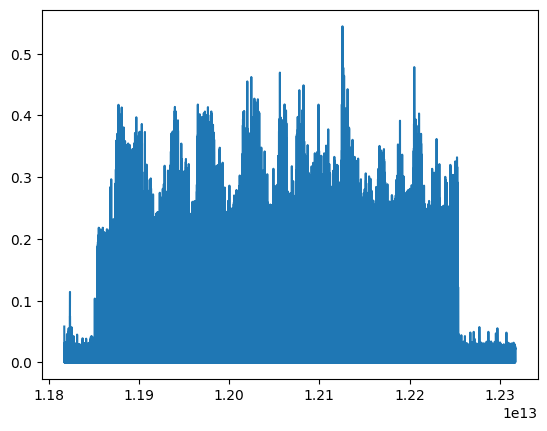

In [4]:
# data cleaning steps for RAPL
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

In [5]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(499987, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  11817131676212    0.000000          0.0          0.0  0.000000   0.000000   
2  11817132610181    0.029358          0.0          0.0  0.029358  31.433495   
3  11817133744396    0.024231          0.0          0.0  0.024231  21.363636   
4  11817134633226    0.022339          0.0          0.0  0.022339  25.132891   
5  11817135717780    0.000000          0.0          0.0  0.000000   0.000000   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  


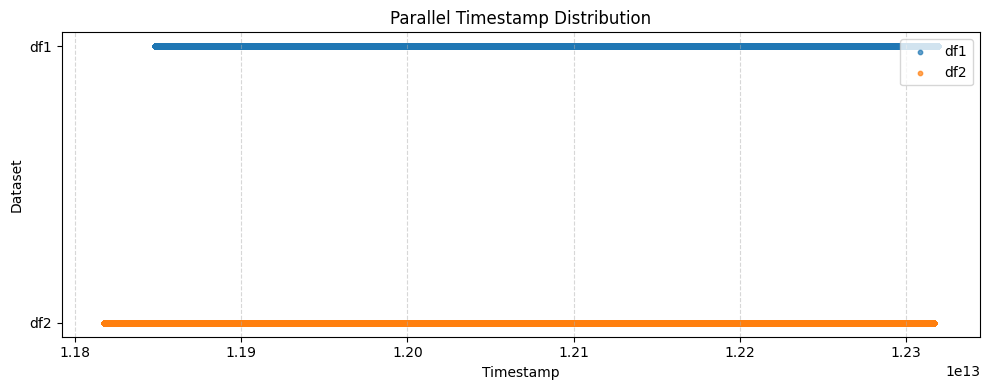

In [6]:
#plot_timestamp_distribution_parallel
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_timestamp_distribution_parallel(df1, df2, time_col="timestamp", label1="df1", label2="df2"):
    """
    Plot two timestamp distributions in parallel (non-overlapping) rows.
    X-axis: timestamp values
    Y-axis: fixed levels to separate datasets visually.
    """

    plt.figure(figsize=(10, 4))

    # fixed y-levels for visual separation
    y1 = [1] * len(df1)
    y2 = [0] * len(df2)

    plt.scatter(df1[time_col], y1, label=label1, alpha=0.7, s=10)
    plt.scatter(df2[time_col], y2, label=label2, alpha=0.7, s=10)

    plt.yticks([0, 1], [label2, label1])
    plt.xlabel("Timestamp")
    plt.ylabel("Dataset")
    plt.title("Parallel Timestamp Distribution")
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_timestamp_distribution_parallel(df, df_rapl_watt)

In [9]:
print(df_rapl_watt.head(5))
df_rapl_watt["timestamp"] = df_rapl_watt["timestamp"] - 8642644546100
print(df.head(5))

        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  11817131676212    0.000000          0.0          0.0  0.000000   0.000000   
2  11817132610181    0.029358          0.0          0.0  0.029358  31.433495   
3  11817133744396    0.024231          0.0          0.0  0.024231  21.363636   
4  11817134633226    0.022339          0.0          0.0  0.022339  25.132891   
5  11817135717780    0.000000          0.0          0.0  0.000000   0.000000   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
        timestamp         A         B         C         D         H         I  \
0  11847837392042  2.024665  0.411796  2.196247  0.446113  2.756747  1.086684   
1  11847837908042  2.058981  0.434674  2.230563  0.446113  2.676676  1.086684   
2  11847838424042  2.058981  0.411796  2.207685  0.446113  2.733870  1.063807   
3  11847838941042  2.001787  0.411796  2.196247  0.434674  2.699553  1.063807   
4  11847839457042  2.024

In [5]:
# plothelper def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None, figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
import matplotlib.pyplot as plt

def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None,
                 figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
    """
    Plot one or more DataFrame columns using matplotlib.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    columns : list of str
        List of column names to plot.
    x_col : str, optional
        Column name to use as the x-axis. If None, use the DataFrame index.
    title : str, optional
        Plot title.
    xlabel, ylabel : str, optional
        Axis labels.
    figsize : tuple, optional
        Figure size.
    style : str, optional
        Line style (default: '-').
    markersize : int, optional
        Marker size (default: 2).
    alpha : float, optional
        Line transparency (default: 0.9).
    legend : bool, optional
        Whether to show a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The plot’s axes object.
    """
    plt.figure(figsize=figsize)

    # Choose x-axis
    x = df[x_col] if x_col else df.index

    for col in columns:
        if col not in df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue
        plt.plot(x, df[col], style, label=col, markersize=markersize, alpha=alpha)

    plt.title(title or "Data Plot")
    plt.xlabel(xlabel or (x_col if x_col else "Index"))
    plt.ylabel(ylabel or "Value")

    if legend:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

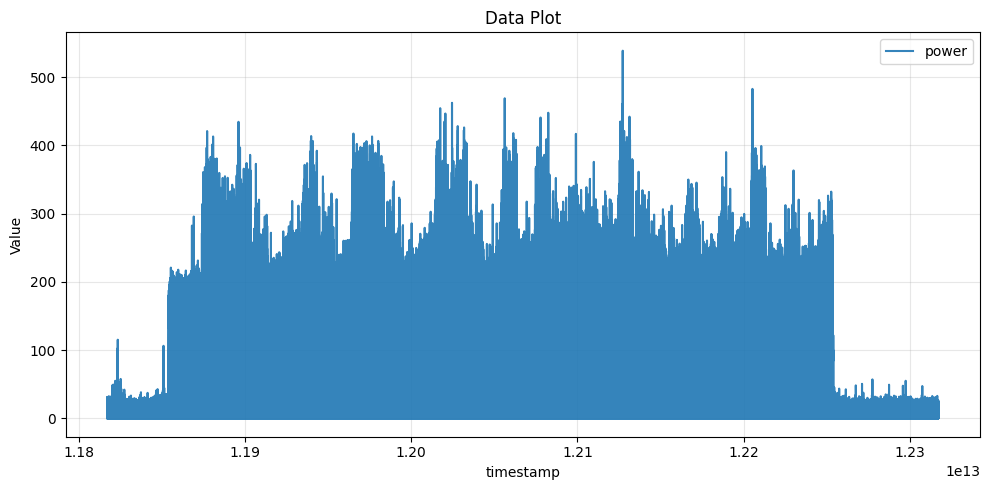

In [49]:
# df_rapl_watt["timestamp_s"] = df_rapl_watt["timestamp"] / 1000_000_000
plot_columns(df=df_rapl_watt, columns=["power"], x_col="timestamp")

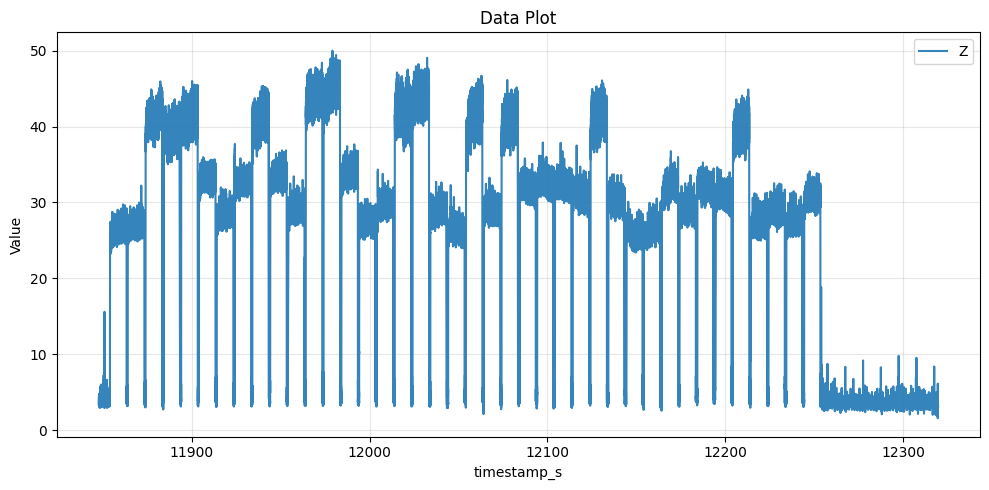

In [50]:
corrected_df["timestamp_s"] = corrected_df["timestamp"] / 1000_000_000
plot_columns(df=corrected_df, columns=["Z"], x_col="timestamp_s")

shuffle the workload later to remove influence of time 
P core and E core 
temperature 
run this workload, stop and run again without allowing the cpu to cool 
the second, third run 

1000023.6940994348
0          NaN
1     933969.0
2    1134215.0
3     888830.0
4    1084554.0
Name: timestamp, dtype: float64
1000023.6940994348
    index       timestamp  energy_pkg  energy_dram  energy_psys    energy  \
2       3  11817133744396    0.024231          0.0          0.0  0.024231   
4       5  11817135717780    0.000000          0.0          0.0  0.000000   
5       6  11817136767095    0.026672          0.0          0.0  0.026672   
9      10  11817140739280    0.020386          0.0          0.0  0.020386   
10     11  11817141750492    0.023743          0.0          0.0  0.023743   

        power  dram_rapl    ts_diff  
2   21.363636        0.0  1134215.0  
4    0.000000        0.0  1084554.0  
5   25.418833        0.0  1049315.0  
9   20.117535        0.0  1013332.0  
10  23.479424        0.0  1011212.0  


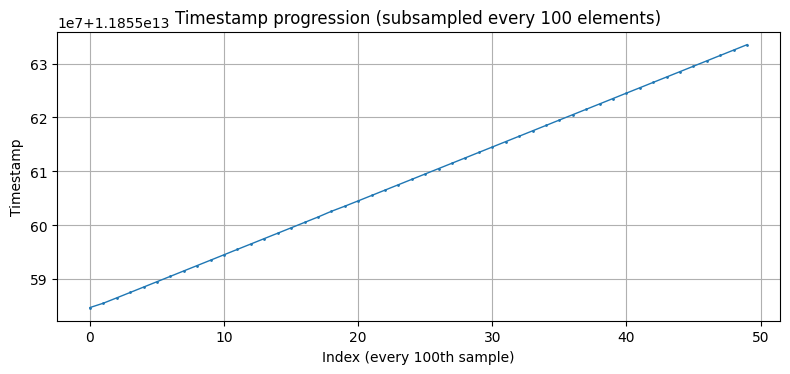

In [51]:
print(df_rapl_watt["timestamp"].diff().dropna().mean())

df_time_explore = df_rapl_watt.reset_index(names="index")
diff_mean = df_time_explore["timestamp"].diff().dropna().mean()
print(df_time_explore["timestamp"].diff().head())
print(diff_mean)
df_time_explore["ts_diff"] = df_time_explore["timestamp"].diff()
outliers = df_time_explore[df_time_explore["ts_diff"] > diff_mean]
print(outliers.head())

ts_sub_1 = df_rapl_watt["timestamp"].iloc[38450:38500].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1, markersize=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [7]:
import pandas as pd
import numpy as np

def merge_by_bracketing_average(df1, df2, time_col="timestamp", t=500_000, suffix="_2"):
    """
    Bracket-merge df1 with df2 using integer timestamp arithmetic only.
    """

    # Sort
    df1 = df1.sort_values(time_col).reset_index(drop=True)
    df2 = df2.sort_values(time_col).reset_index(drop=True)

    t1 = df1[time_col].to_numpy(np.int64)
    t2 = df2[time_col].to_numpy(np.int64)

    # Get nearest right index in df2
    idx_right = np.searchsorted(t2, t1, side="left")
    idx_left = idx_right - 1

    # Clip to valid range inside df2
    idx_left = np.clip(idx_left, 0, len(t2) - 1)
    idx_right = np.clip(idx_right, 0, len(t2) - 1)

    # Gather timestamps
    t_left  = t2[idx_left]
    t_right = t2[idx_right]

    # Integer differences
    diff_left  = np.abs(t1 - t_left)
    diff_right = np.abs(t1 - t_right)

    # Require that left < t1 < right AND both within tolerance
    valid = (
        (diff_left <= t) &
        (diff_right <= t) &
        (t_left <= t1) &
        (t_right >= t1) &
        (idx_left != idx_right)
    )

    if not valid.any():
        return df1.iloc[0:0]   # empty

    # Filter indices
    df1_valid = df1[valid].reset_index(drop=True)
    left_idx  = idx_left[valid]
    right_idx = idx_right[valid]

    left_df2  = df2.iloc[left_idx].reset_index(drop=True)
    right_df2 = df2.iloc[right_idx].reset_index(drop=True)

    # Integer midpoint timestamp
    # (safe: stays int64)
    merged_time = (left_df2[time_col].to_numpy(np.int64)
                   + right_df2[time_col].to_numpy(np.int64)) // 2

    # Average only numeric columns, integer arithmetic
    df2_avg = left_df2.copy()
    numeric_cols = df2_avg.select_dtypes(include=[np.number]).columns

    for c in numeric_cols:
        df2_avg[c] = (left_df2[c].to_numpy(np.int64)
                      + right_df2[c].to_numpy(np.int64)) // 2

    # Write midpoint timestamp to separate column
    df2_avg[time_col + suffix] = merged_time

    # Merge side-by-side
    merged = pd.concat(
        [df1_valid.reset_index(drop=True),
         df2_avg.add_suffix(suffix)],
        axis=1
    )

    # Integer difference
    merged["timestamp_diff"] = (
        merged[time_col + suffix] - merged[time_col]
    ).astype(np.int64)

    return merged

df_rapl_watt["timestamp_1"] = df_rapl_watt["timestamp"]
corrected_df["timestamp_2"] = corrected_df["timestamp"]

print(df_rapl_watt.shape)
rapl_teensy_merged = merge_by_bracketing_average(df1=df_rapl_watt, df2=corrected_df, time_col="timestamp", t=500000, suffix="_2")
print(rapl_teensy_merged.shape)

(499987, 8)
(438241, 27)


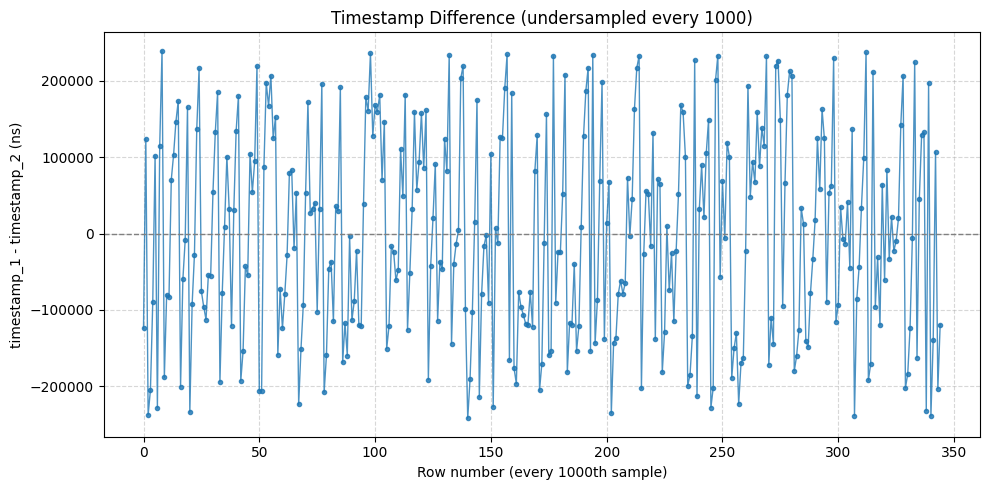

In [9]:
import matplotlib.pyplot as plt

def plot_timestamp_difference_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=1000, title=None
):
    """
    Plot undersampled difference between two timestamp columns,
    using row number as the X-axis.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Custom plot title.
    """

    # undersample
    df_sub = merged_df.iloc[0:345000].iloc[::step].copy()

    # compute difference
    diff = df_sub[ts1_col] - df_sub[ts2_col]
    diff = diff.replace([np.inf, -np.inf], np.nan)

    # x-axis as row number
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.plot(x, diff, marker=".", linestyle="-", linewidth=1, alpha=0.8)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel(f"{ts1_col} - {ts2_col} (ns)")
    plt.title(title or f"Timestamp Difference (undersampled every {step})")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_timestamp_difference_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

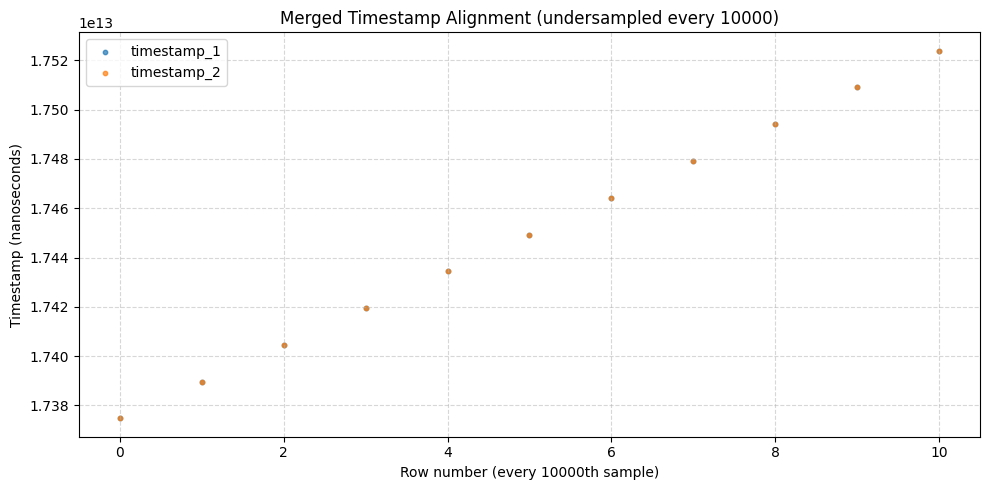

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_merged_timestamps_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=10000, title=None
):
    """
    Plot both merged timestamp columns vs. row number, undersampled, using dots instead of lines.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame after merge_asof() containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Optional title for the plot.
    """

    # undersample
    df_sub = merged_df.iloc[::step].copy()
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.scatter(x, df_sub[ts1_col], label=ts1_col, s=10, alpha=0.7)
    plt.scatter(x, df_sub[ts2_col], label=ts2_col, s=10, alpha=0.7)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel("Timestamp (nanoseconds)")
    plt.title(title or f"Merged Timestamp Alignment (undersampled every {step})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_merged_timestamps_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

In [8]:
rapl_teensy_merged["cpu_total"] = (rapl_teensy_merged["Y_2"] + rapl_teensy_merged["Z_2"] +rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"] )
rapl_teensy_merged["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])
rapl_teensy_merged["timestamp_s"] = rapl_teensy_merged["timestamp"] / 1000_000_000
rapl_teensy_merged.head(3)


,timestamp,energy_pkg,energy_dram,energy_psys,energy,power,dram_rapl,timestamp_1,timestamp_2,A_2,...,P_2,Q_2,R_2,U_2,V_2,timestamp_2_2,timestamp_diff,cpu_total,abs_total,timestamp_s
0,11847837526156,0.023621,0.0,0.0,0.023621,23.593214,0.0,11847837526156,11847837650042,2,...,2,1,1,3,5,11847837650042,123886,14,26,11847.837526
1,11847838524102,0.021423,0.0,0.0,0.021423,21.467434,0.0,11847838524102,11847838682542,2,...,2,1,1,3,5,11847838682542,158440,14,26,11847.838524
2,11847839525895,0.000000,0.0,0.0,0.000000,0.000000,0.0,11847839525895,11847839715042,2,...,2,1,1,3,5,11847839715042,189147,14,26,11847.839526


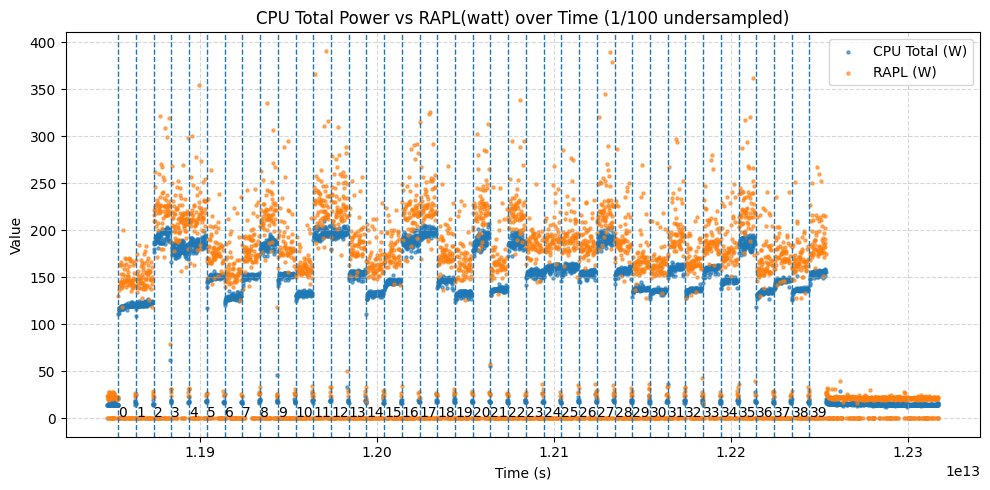

#0: w1:fp64:idle
#1: w1:fp64:idle
#2: w1:int128:idle
#3: w1:int32:idle
#4: w1:int64:idle
#5: w1:AVX2:idle
#6: w1:fp32:idle
#7: w1:AVX2:idle
#8: w1:int32:idle
#9: w1:AVX2:idle
#10: w1:fp64:idle
#11: w1:int128:idle
#12: w1:int128:idle
#13: w1:SSE2:idle
#14: w1:fp32:idle
#15: w1:SSE:idle
#16: w1:int64:idle
#17: w1:int128:idle
#18: w1:SSE:idle
#19: w1:fp32:idle
#20: w1:int64:idle
#21: w1:MMX:idle
#22: w1:int32:idle
#23: w1:AVX2:idle
#24: w1:AVX:idle
#25: w1:AVX:idle
#26: w1:SSE2:idle
#27: w1:int64:idle
#28: w1:SSE2:idle
#29: w1:MMX:idle
#30: w1:fp64:idle
#31: w1:AVX:idle
#32: w1:MMX:idle
#33: w1:AVX:idle
#34: w1:SSE:idle
#35: w1:int32:idle
#36: w1:fp32:idle
#37: w1:SSE:idle
#38: w1:MMX:idle
#39: w1:SSE2:idle


In [9]:
import matplotlib.pyplot as plt
import pickle

def plot_cpu_vs_energy(df, time_col="timestamp_s", cpu_col="cpu_total", energy_col="power", sample_factor=1000, segments=[]):
    """
    Plot CPU total power and energy over time with small points and different colors,
    undersampling for performance.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp, cpu_total, and energy columns.
    time_col : str
        Name of the timestamp column (x-axis).
    cpu_col : str
        Name of the CPU total column (y-axis, one color).
    energy_col : str
        Name of the energy column (y-axis, another color).
    sample_factor : int, default 100
        Plot every Nth row for undersampling.
    """
    # Undersample
    df_sub = df.iloc[::sample_factor, :]

    plt.figure(figsize=(10, 5))
    plt.scatter(df_sub[time_col], df_sub[cpu_col], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    plt.scatter(df_sub[time_col], df_sub[energy_col], s=5, color='tab:orange', alpha=0.6, label="RAPL (W)")

    plt.xlabel("Time (s)")
    plt.ylabel("Value")
    plt.title(f"CPU Total Power vs RAPL(watt) over Time (1/{sample_factor} undersampled)")
    plt.legend()

    for i,xc in enumerate(segments):
        plt.axvline(x=xc, linestyle="--", linewidth=1)
        plt.text(x = xc, y = 0.9, s=i)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


with open('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)

segments = []
for workload in workloads: 
    segments.append(workload["start_ns"])

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
for i, workload in enumerate(workloads):
    print(f"#{i}: {workload['name']}")

In [10]:
# performs Wilcoxon SIGN-RANK test for each workload type, comparing spontaneous measurement (Power) between RAPL and Measured value
# "Power" for RAPL is computed previously as a function of Reported (Energy delta since last update) / duration of update  

import scipy.stats

def run_tests (snippet, xname= "cpu_total", yname="power"):

    prescriptive = {}
    x = snippet[xname] # measurement
    y = snippet[yname] # rapl
    

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='two-sided', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    prescriptive["W twotail"] = result.statistic
    prescriptive["p twotail"] = result.pvalue # have to report this becaue no theory supporting onesided test.

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='less', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)

    # prescriptive["W less"] = result.statistic
    # prescriptive["p less"] = result.pvalue

    result = scipy.stats.wilcoxon(x, y, zero_method='wilcox', correction=False, alternative='greater', method='auto', axis=0, nan_policy='propagate', keepdims=False)
    print(result)
    # prescriptive["W"] = result.statistic
    # prescriptive["p value"] = result.pvalue



    print("onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y")

    # Effect size (Rank biserial correlation)
    def calculate_directional_r(group1, group2):
        res = scipy.stats.mannwhitneyu(group1, group2, alternative='two-sided') #workaround because wilcoxon rank sum in scipy returns test statistic of X or Y depends on which one is smaller. which means we dont know the direction.
        U1 = res.statistic
        n1, n2 = len(group1), len(group2)
        
        # Calculate Rank-Biserial Correlation
        # This formula ensures: 
        # Positive r = Group 1 is greater
        # Negative r = Group 2 is greater
        r = (2 * U1 / (n1 * n2)) - 1
        
        return r, res.pvalue

    # Example
    effectsize, p = calculate_directional_r(x, y)

    print(f"effectsize {effectsize}")
    print("rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect")
    prescriptive["rank biserial effectsize"] = effectsize

    print(f"x median {x.median()}")
    print(f"y median {y.median()}")

    # mean error
    me = (x - y).mean()
    print(me)
    prescriptive["me"] = me
    # mean absolute error
    mae = (x - y).abs().mean()
    print(mae)
    prescriptive["mae"] = mae

    prescriptive["xname"] = xname
    prescriptive["yname"] = yname 
    return prescriptive

with open('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] > start_ns) & (rapl_teensy_merged["timestamp"] < end_ns)])

samples_by_workload = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload.keys():
        df1 = samples_by_workload[workload["name"]]
        df2 = samples[i]
        samples_by_workload[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload[workload["name"]] = samples[i]
    # print(workload["name"])
    # print(samples_by_workload[workload["name"]].shape)

# no normalization for wilcoxon.    
# for i, workload in enumerate(workloads):
#     df1 = samples_by_workload[workload["name"]]
#     df1["diff"] = df1["power"] - df1["cpu_total"]
#     df1["diff_normalized"] = df1["diff"] / df1["cpu_total"] #use sensor measurement as base for normalization
 
# for i, sample in enumerate(list(samples_by_workload.values())):
#     print(type(sample))
#     # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
#     plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
#     plt.show()

results = []
for i, sample in enumerate(samples_by_workload.values()):
    result = run_tests(sample)
    result["workload name"] = list(samples_by_workload.keys())[i].split(':')[1]
    results.append(result)
df_descriptive = pd.DataFrame(results)
df_descriptive['significance'] = np.where(df_descriptive['p twotail'] < 0.001, "p < 0.001", "ns")
#effect size interprept.
conditions = [
    df_descriptive["rank biserial effectsize"].abs() >= 0.5,
    df_descriptive["rank biserial effectsize"].abs() >= 0.3,
    df_descriptive["rank biserial effectsize"].abs() >= 0.1
]
#Labels
choices = ["Large", "Medium", "Small"]
df_descriptive['effectsize word'] = np.select(conditions, choices, default="Negligible")
# directionality 
conditions = [
    df_descriptive["rank biserial effectsize"] > 0, 
    df_descriptive["rank biserial effectsize"] == 0,
    df_descriptive["rank biserial effectsize"] < 0
]
choices = ["X is greater", "Equal", "X is smaller"]
df_descriptive['direction'] = np.select(conditions, choices, default="NA")
df_descriptive.to_csv("power_descriptive_statistics_wilcoxon_rank_biserial.csv", index=False)
# snippets = []
# results = []
# for i in range (0, len(segments) - 1): 
#     snippets.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= segments[i]) & (rapl_teensy_merged["timestamp"] <= segments[i + 1])])
#     print(f"workload # {i}")
#     result = run_tests(snippets[i])
#     results.append(result)

# df_descriptive = pd.DataFrame(results)
# df_descriptive.to_csv("descriptive_statistics_wilcoxon.csv", index=False)


target_cols = ["p value"]

print(df_descriptive.dtypes)
df_descriptive_latexfriendly = df_descriptive.apply(lambda col: 
    col.map(lambda x: "p < 0.001" if (isinstance(x, (int, float)) and x < 0.001) else x) 
    if col.name in target_cols else col
)
df_descriptive_latexfriendly = df_descriptive_latexfriendly.applymap(lambda x: f"${x :.3f}$" if isinstance(x, (int, float)) else x) #g for significant

latex_code = df_descriptive_latexfriendly.to_latex(
    column_format='@{}lrr@{}', 
    escape=False,
    index=False  # Set to False if you don't want the index
)
print(latex_code)

print("if you notice the effectsize is negative and the ME and MAE isnt, this is because scipy.stats.wilcoxon pick whichever statistic is smaller to report. I dont control it.")


WilcoxonResult(statistic=np.float64(300749875.5), pvalue=np.float64(1.4619615228584988e-120))
WilcoxonResult(statistic=np.float64(300749875.5), pvalue=np.float64(7.309807614292494e-121))
WilcoxonResult(statistic=np.float64(300749875.5), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.3523312260665309
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 124.0
y median 148.06674194335938
8.748078628926528
53.43819017426603
WilcoxonResult(statistic=np.float64(298702475.5), pvalue=np.float64(4.627568043597516e-130))
WilcoxonResult(statistic=np.float64(298702475.5), pvalue=np.float64(2.313784021798758e-130))
WilcoxonResult(statistic=np.float64(298702475.5), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.3332522191218784
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large e

C:\Users\andyh\AppData\Local\Temp\ipykernel_4356\2422731789.py:150: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_descriptive_latexfriendly = df_descriptive_latexfriendly.applymap(lambda x: f"${x :.3f}$" if isinstance(x, (int, float)) else x) #g for significant


[{'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:12', 'start_ns': 11854073309704, 'end_wall': '2026-05-05 19:04:22', 'end_ns': 11864079625096, 'duration': 10.00626910199935, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:fp64:idle', 'start_wall': '2026-05-05 19:04:22', 'start_ns': 11864079794688, 'end_wall': '2026-05-05 19:04:32', 'end_ns': 11874085526834, 'duration': 10.005680668999048, 'command': './code/combine_instruction --cores 20 --workload1 fp64 --workload2 idle --duration 10'}, {'name': 'w1:int128:idle', 'start_wall': '2026-05-05 19:04:32', 'start_ns': 11874085727623, 'end_wall': '2026-05-05 19:04:42', 'end_ns': 11884091298049, 'duration': 10.005530438998903, 'command': './code/combine_instruction --cores 20 --workload1 int128 --workload2 idle --duration 10'}, {'name': 'w1:int32:idle', 'start_wall': '2026-05-05 19:04:42', 'start_ns': 11884091448086, 'end_wall': '2026-05-05 19:04:52', 'end_ns': 11894096

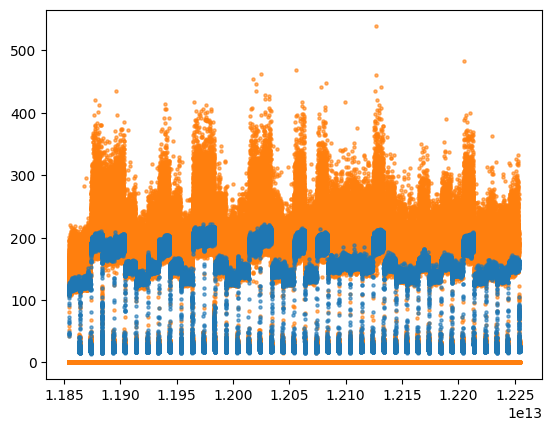

In [11]:
# this section intends to use a jumping window to split the observation into sections where we can observe if the sections are uniform.

# experiment info
with open('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
print(workloads)

workload_start = workloads[0]["start_ns"]
workload_end = workloads[-1]["end_ns"]

print(f"experiment duration: {workload_start} to {workload_end}, lasted {(workload_end - workload_start)/1000_000_000} s")


df_teensy_original = corrected_df
df_teensy_original["cpu_total"] = df_teensy_original["Y"] + df_teensy_original["Z"] + df_teensy_original["U"] + df_teensy_original["V"]
df_rapl_original = df_rapl_watt
print(df_teensy_original.columns) 
print(df_teensy_original.shape)
print(df_rapl_original.columns) 
print(df_rapl_original.shape)

df_teensy_1 = df_teensy_original.set_index("timestamp")
df_rapl_1 = df_rapl_original.set_index("timestamp")
df_merged_outer = pd.merge(df_teensy_1, df_rapl_1, left_index=True, right_index=True, how='outer')
print(df_merged_outer.head())

df_merged_outer = df_merged_outer[(df_merged_outer.index >= workload_start) & (df_merged_outer.index <= workload_end)]

# 1. Create a mask and Group IDs
is_not_nan = df_merged_outer['power'].notna()
group_id = is_not_nan.cumsum()

# 2. Count how many NaNs are in each group
# We only group the rows where 'a' was actually NaN
nan_counts = df_merged_outer[df_merged_outer['power'].isna()].groupby(group_id).size()

# 3. Include the "Zeroes"
# Some non-NaN values might have 0 NaNs following them.
# We reindex to include every group ID from 1 to the total count of non-NaNs.
total_non_nans = is_not_nan.sum()
all_gaps = nan_counts.reindex(np.arange(1, total_non_nans + 1), fill_value=0)

# 4. Final Statistics
stats = {
    'mean': all_gaps.mean(),
    'median': all_gaps.median(),
    'max': all_gaps.max(),
    'min': all_gaps.min()
}

print(stats)
all_gaps = all_gaps.sort_values(ascending = False)
#print(all_gaps.head())
plt.scatter(df_merged_outer.index, df_merged_outer["power"], s=5, color='tab:orange', alpha=0.6, label="rapl")
plt.scatter(df_merged_outer.index, df_merged_outer["cpu_total"], s=5, color='tab:blue', alpha=0.6, label="measured")
plt.show()


In [89]:
print(df_merged_outer[df_merged_outer["cpu_total"] == 0].shape)

(0, 26)


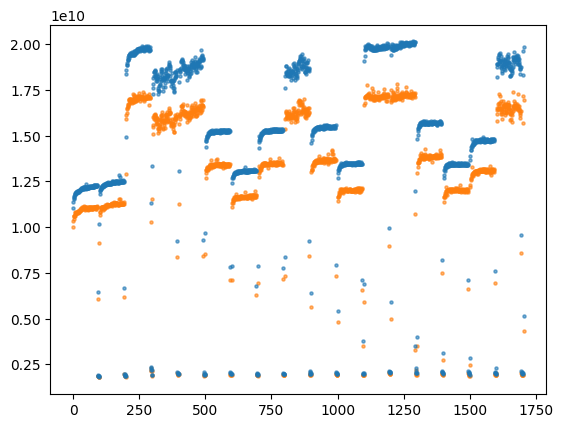

In [12]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid

def integrate_dual_cadence(df, col1, col2, window = 10):
    # 1. Identify rows where 'a' is valid
    is_a_valid = df[col1].notna()
    
    # 2. Create Window IDs based on every 10 valid 'a' values
    # cumsum increments at every valid 'a', then // 10 groups them
    # We subtract 1 so the first group is 0
    a_group_id = (is_a_valid.cumsum() - 1) // window
    
    # 3. Handle Column B's range:
    # Column B needs to integrate everything from the first valid 'a' in the group
    # to just before the first 'a' of the NEXT group.
    # a_group_id naturally covers this range for every row.
    
    # 4. Define the integration logic
    def perform_integration(group):
        # -- Integration for A --
        # Filter only non-NaN a values
        a_data = group[col1].dropna()
        # Trapezoid needs at least 2 points to calculate area
        area_a = scipy.integrate.trapezoid(y=a_data.values, x=a_data.index, dx=1.0, axis=-1) if len(a_data) > 1 else 0
        
        # -- Integration for B --
        # Filter only non-NaN b values
        # This takes all rows in the 10-point 'a' window
        b_data = group[col2].dropna()
        area_b = scipy.integrate.trapezoid(y=b_data.values, x=b_data.index, dx=1.0, axis=-1) if len(b_data) > 1 else 0
        # print(a_data.index)
        # print(len(a_data.index))
        # print(b_data.index)
        # print(len(b_data.index))
        # print("break")

        return pd.Series({'area_a': area_a, 'area_b': area_b})

    # 5. Execute GroupBy
    # We only process groups where a_group_id >= 0 (ignores NaNs at the very start)
    results_df = df[a_group_id >= 0].groupby(a_group_id).apply(perform_integration)
    
    return results_df

# Example usage with dummy data
# df = pd.DataFrame({'a': [...], 'b': [...]})
integrated_results = integrate_dual_cadence(df_merged_outer.head(500000), "power", "cpu_total", window=100)

plt.scatter(integrated_results.index, integrated_results["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
plt.scatter(integrated_results.index, integrated_results["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
plt.show()

In [13]:
with open('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)

samples_kw = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples_kw.append(df_merged_outer[(df_merged_outer.index > start_ns) & (df_merged_outer.index < end_ns)])

samples_integrals_kw = []
for sample in samples_kw: 
    samples_integrals_kw.append(integrate_dual_cadence(sample, "power", "cpu_total", window=100))

# for i, sample in enumerate(samples):
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     plt.show()

samples_by_workload_kw = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload_kw.keys():
        df1 = samples_by_workload_kw[workload["name"]]
        df2 = samples_integrals_kw[i]
        samples_by_workload_kw[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload_kw[workload["name"]] = samples_integrals_kw[i]
    # print(workload["name"])
    # print(samples_by_workload_kw[workload["name"]].shape)
    
for i, workload in enumerate(workloads):
    df1 = samples_by_workload_kw[workload["name"]]
    df1["diff"] = df1["area_a"] - df1["area_b"]
    df1["diff_normalized"] = df1["diff"] / df1["area_b"]

for i, sample in enumerate(list(samples_by_workload_kw.values())):
    print(type(sample))
    # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
    # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
    # plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
    # plt.show()
    

    

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

# plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
# for i, workload in enumerate(workloads):
#     print(f"#{i}: {workload['name']}")



<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


2159.4429458929717
0.0
group
0    3259.794554
8    2992.853960
5    2937.997525
7    2339.254950
6    2072.467822
9    2031.881188
4    1846.272277
2    1085.259901
3     985.524752
1     653.693069
Name: overall_rank, dtype: float64


C:\Users\andyh\AppData\Local\Temp\ipykernel_4356\3602021402.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)


         median      mean
group                    
0     -0.098518 -0.093876
1     -0.136081 -0.129365
2     -0.128384 -0.121201
3     -0.130546 -0.122778
4     -0.116096 -0.110334
5     -0.104131 -0.099563
6     -0.113958 -0.108161
7     -0.110922 -0.105856
8     -0.103486 -0.098602
9     -0.114499 -0.108194
Index([1, 3, 2, 4, 9, 6, 7, 5, 8, 0], dtype='int64', name='group')
       overall_rank    median      mean  orderPositiveCorrelation
group                                                            
0       3259.794554 -0.098518 -0.093876                         9
1        653.693069 -0.136081 -0.129365                         0
2       1085.259901 -0.128384 -0.121201                         2
3        985.524752 -0.130546 -0.122778                         1
4       1846.272277 -0.116096 -0.110334                         3
5       2937.997525 -0.104131 -0.099563                         7
6       2072.467822 -0.113958 -0.108161                         5
7       2339.254950 -0.1109

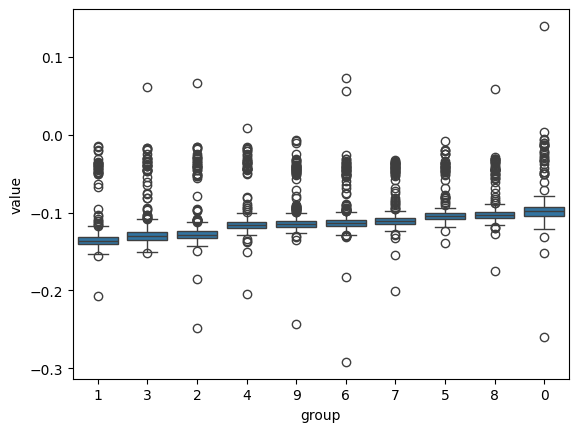

dict_keys(['w1:fp64:idle', 'w1:int128:idle', 'w1:int32:idle', 'w1:int64:idle', 'w1:AVX2:idle', 'w1:fp32:idle', 'w1:SSE2:idle', 'w1:SSE:idle', 'w1:MMX:idle', 'w1:AVX:idle'])
   group    workloadname
0      0    w1:fp64:idle
1      1  w1:int128:idle
2      2   w1:int32:idle
3      3   w1:int64:idle
4      4    w1:AVX2:idle
5      5    w1:fp32:idle
6      6    w1:SSE2:idle
7      7     w1:SSE:idle
8      8     w1:MMX:idle
9      9     w1:AVX:idle
   group  overall_rank    median      mean  orderPositiveCorrelation  \
0      0   3259.794554 -0.098518 -0.093876                         9   
1      1    653.693069 -0.136081 -0.129365                         0   
2      2   1085.259901 -0.128384 -0.121201                         2   
3      3    985.524752 -0.130546 -0.122778                         1   
4      4   1846.272277 -0.116096 -0.110334                         3   
5      5   2937.997525 -0.104131 -0.099563                         7   
6      6   2072.467822 -0.113958 -0.108161      

C:\Users\andyh\AppData\Local\Temp\ipykernel_4356\3602021402.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_with_names)


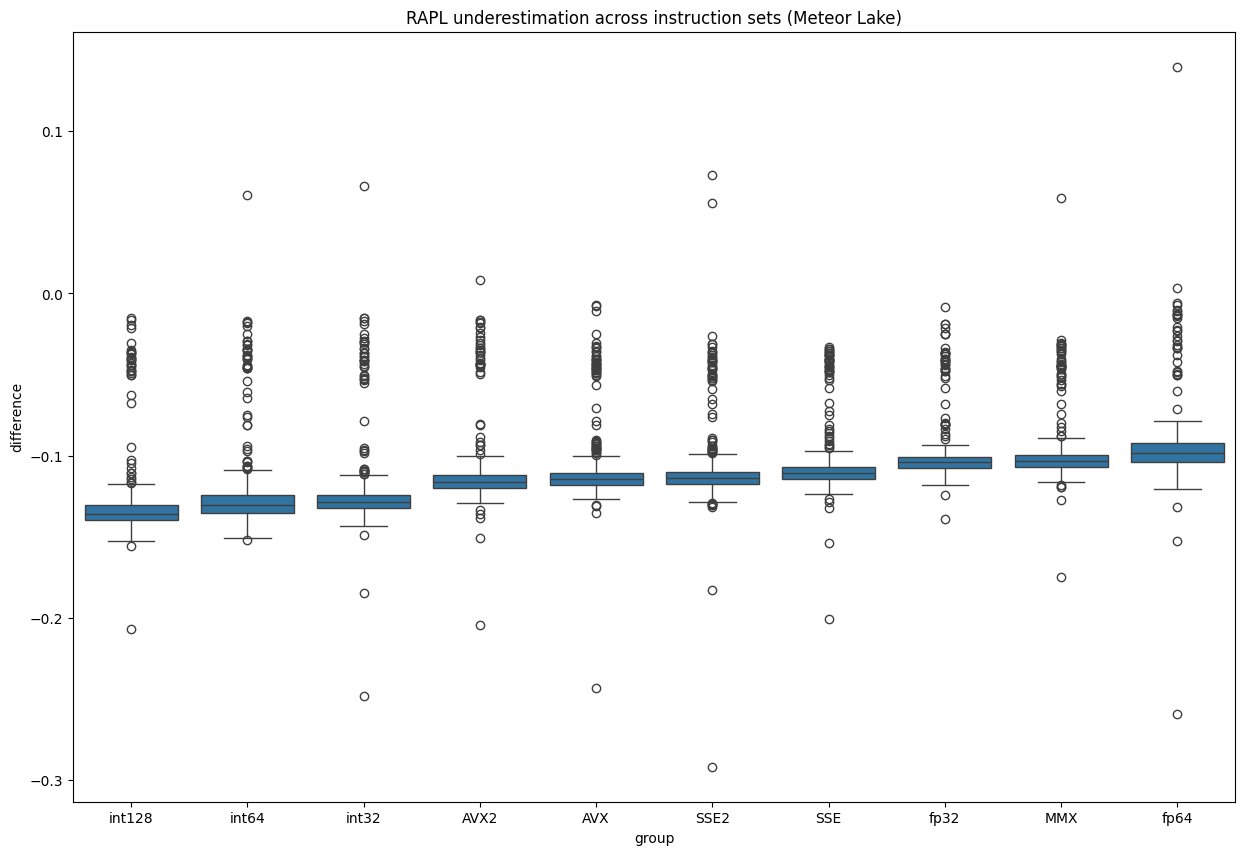

In [16]:
# perform kruskal wallis H test on normalized difference for data collected in each instruction set type workload.
# visualize using box plot 
# performs dunns test to determining if the differences are statistically significant 

writepath = "./"

from scipy.stats import kruskal

kruskal_sample = []
for sample in list(samples_by_workload_kw.values()):
    kruskal_sample.append(sample["diff_normalized"])

# Perform Kruskal-Wallis H-test
result = kruskal(*kruskal_sample)

print(result.statistic)
print(result.pvalue)

df_kruskal_display = pd.DataFrame(columns=["value", "group"])
for i, sample in enumerate(kruskal_sample):
    sample_df = pd.DataFrame()
    sample_df["value"] = sample
    sample_df["group"] = i
    df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)

from scipy.stats import rankdata
df_kruskal_descriptive = pd.DataFrame()

# Combine your data into a DataFrame
# Assume 'value' is the score and 'group' is the category
df_kruskal_display['overall_rank'] = rankdata(df_kruskal_display['value'])

# Get the ranking of the groups
group_rankings = df_kruskal_display.groupby('group')['overall_rank'].mean().sort_values(ascending=False)
df_kruskal_descriptive = df_kruskal_display.groupby("group")["overall_rank"].mean()
print(group_rankings)

import seaborn as sns
import matplotlib.pyplot as plt

# Sort the groups by their median value to visualize the ranking
order = df_kruskal_display.groupby('group')['value'].median().sort_values().index
df_kruskal_median = pd.DataFrame()
df_kruskal_median["median"] = df_kruskal_display.groupby("group")["value"].median()
df_kruskal_median["mean"] = df_kruskal_display.groupby("group")["value"].mean()

df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_kruskal_median, on="group")
print(df_kruskal_median)
#df_kruskal_order = df_kruskal_order.set_index("order")
print(order)
order_by_group = pd.Series(range(len(order)), index=order).sort_index()
df_kruskal_descriptive["orderPositiveCorrelation"] = order_by_group
print(df_kruskal_descriptive)

sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
plt.show()
print(samples_by_workload_kw.keys())
df_workload_results = pd.DataFrame()
df_workload_results["workloadname"] = samples_by_workload_kw.keys()
df_workload_results = df_workload_results.reset_index(names="group")
print(df_workload_results)
df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_workload_results, on="group")
print(df_kruskal_descriptive)
df_kruskal_descriptive['workloadname'] = df_kruskal_descriptive['workloadname'].apply(lambda x: x.split(':')[1])
print(df_kruskal_descriptive)
df_kruskal_descriptive.to_csv((writepath + "Energy_kruskal_results_descriptive_workloadranking.csv"), index = False)
workload_name_mapping = df_kruskal_descriptive.set_index('group')['workloadname'].to_dict()


import scikit_posthocs as sp

# Assuming 'data' is your list of 10 groups
# We pass the list directly to the dunn test function
print("columns")
print(df_kruskal_display.columns)
p_values = sp.posthoc_dunn(df_kruskal_display,val_col="value", group_col="group", p_adjust='bonferroni')
p_values = p_values.mask(p_values < 0.001, "p < 0.001")

p_values = p_values.rename(index=workload_name_mapping, columns=workload_name_mapping)
print(p_values)
p_values.to_csv((writepath + "Energy_dunn_posthoc_pairwise_workload_comparison.csv"))

# df_kruskal_display["workload name"] = df_kruskal_display["group"].map(workload_name_mapping)
# sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
order_with_names = [workload_name_mapping.get(id) for id in order]
plt.figure(figsize=(15, 10))
ax = sns.boxplot(data=df_kruskal_display, x='group', y='value', order=order)
# override the tick labels 
ax.set_xticklabels(order_with_names)
plt.title("RAPL underestimation across instruction sets (Meteor Lake)")
plt.ylabel("difference")
plt.show()




In [25]:
#print(samples_by_workload_kw)
#print(samples_by_workload_kw['w1:int128:idle'].columns)
print(samples_by_workload_kw['w1:int128:idle']['area_a'])

power
0      1.473744e+10
1      1.596577e+10
2      1.625007e+10
3      1.643110e+10
4      1.636638e+10
           ...     
96     1.976470e+09
97     1.971994e+09
98     1.958130e+09
99     1.951634e+09
100    8.626368e+07
Name: area_a, Length: 404, dtype: float64


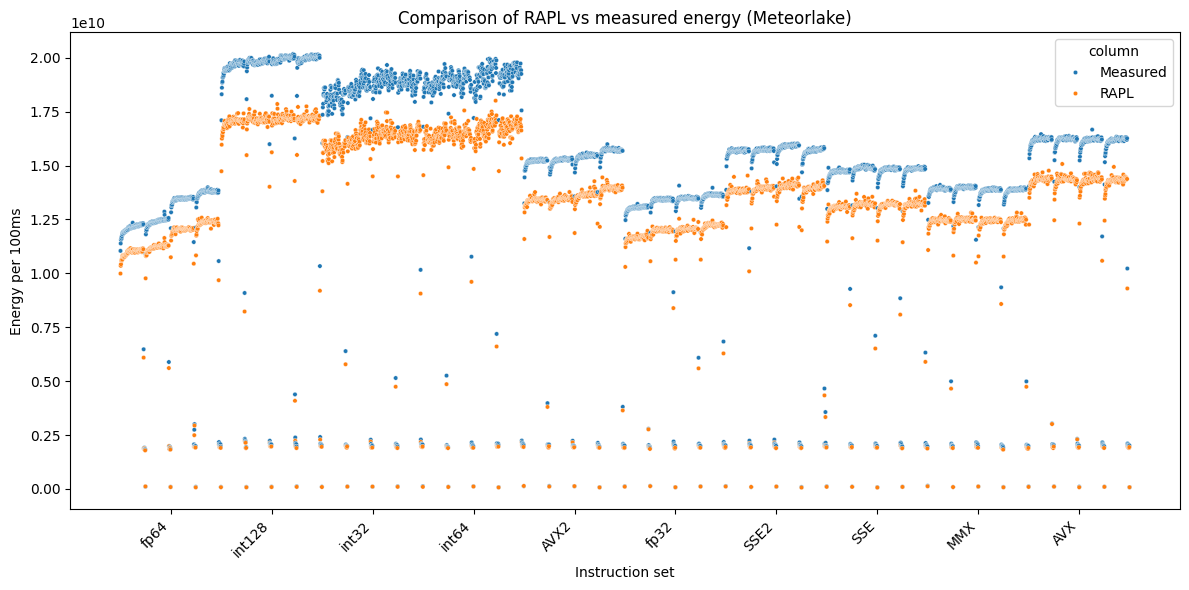

In [37]:
samples_by_workload_kw_display = {}
for key, df in samples_by_workload_kw.items():
    samples_by_workload_kw_display[key.split(':')[1]] = samples_by_workload_kw[key]



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
x_pos = 0
group_centers = []
group_labels = []

for key, df in samples_by_workload_kw_display.items():

    n = len(df)

    xs = list(range(x_pos, x_pos + n))

    for x, (_, row) in zip(xs, df.iterrows()):
        rows.append({"x": x, "value": row["area_b"], "column": "Measured"})
        rows.append({"x": x, "value": row["area_a"], "column": "RAPL"})
       

    group_centers.append(x_pos + (n - 1) / 2)
    group_labels.append(key)

    x_pos += n + 1  # gap between groups

plot_df = pd.DataFrame(rows)

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=plot_df,
    x="x",
    y="value",
    hue="column",
    s= 10,
)

plt.xticks(group_centers, group_labels, rotation=45, ha="right")
plt.xlabel("Instruction set")
plt.ylabel("Energy per 100ms")
plt.title("Comparison of RAPL vs measured energy (Meteorlake)")
plt.tight_layout()
plt.savefig(
    "meteorenergy.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()



In [ ]:
for key in samples_by_workload_kw.keys():
    print(samples_by_workload_kw[key].columns)


Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')
Index(['area_a', 'area_b', 'diff', 'diff_normalized'], dtype='object')


In [17]:
# perform pairwise comparison for Energy data between RAPL and Teensy, using Wilconxon ranksum test

with open('C:/Users/andyh/Downloads/serialreceive/pc2 instructiontype_expanded_withlogs/runinfo.pkl', "rb") as file: 
    workloads = pickle.load(file)
#print(workloads)


# samples = []
# for workload in workloads: 
#     start_ns = workload["start_ns"]
#     end_ns = workload["end_ns"]
#     workload_name = workload["name"]
#     samples.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] > start_ns) & (rapl_teensy_merged["timestamp"] < end_ns)])

# samples_by_workload = {}
# for i, workload in enumerate(workloads):
#     if workload["name"] in samples_by_workload.keys():
#         df1 = samples_by_workload[workload["name"]]
#         df2 = samples[i]
#         samples_by_workload[workload["name"]] = pd.concat([df1, df2], axis =0)
#     else: 
#         samples_by_workload[workload["name"]] = samples[i]
    # print(workload["name"])
    # print(samples_by_workload[workload["name"]].shape)

# no normalization for wilcoxon.    
# for i, workload in enumerate(workloads):
#     df1 = samples_by_workload[workload["name"]]
#     df1["diff"] = df1["power"] - df1["cpu_total"]
#     df1["diff_normalized"] = df1["diff"] / df1["cpu_total"] #use sensor measurement as base for normalization
 
# for i, sample in enumerate(list(samples_by_workload.values())):
#     print(type(sample))
#     # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
#     plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
#     plt.show()

results = []
for i, sample in enumerate(samples_by_workload_kw.values()):
    result = run_tests(sample, xname="area_a", yname="area_b")
    result["workload name"] = list(samples_by_workload_kw.keys())[i].split(':')[1]
    results.append(result)
df_descriptive = pd.DataFrame(results)
df_descriptive['significance'] = np.where(df_descriptive['p twotail'] < 0.001, "p < 0.001", "ns")
#effect size interprept.
conditions = [
    df_descriptive["rank biserial effectsize"].abs() >= 0.5,
    df_descriptive["rank biserial effectsize"].abs() >= 0.3,
    df_descriptive["rank biserial effectsize"].abs() >= 0.1
]
#Labels
choices = ["Large", "Medium", "Small"]
df_descriptive['effectsize word'] = np.select(conditions, choices, default="Negligible")
# directionality 
conditions = [
    df_descriptive["rank biserial effectsize"] > 0, 
    df_descriptive["rank biserial effectsize"] == 0,
    df_descriptive["rank biserial effectsize"] < 0
]
choices = ["X is greater", "Equal", "X is smaller"]
df_descriptive['direction'] = np.select(conditions, choices, default="NA")
df_descriptive.to_csv("Energy_descriptive_statistics_wilcoxon_rank_biserial.csv", index=False)
# snippets = []
# results = []
# for i in range (0, len(segments) - 1): 
#     snippets.append(rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= segments[i]) & (rapl_teensy_merged["timestamp"] <= segments[i + 1])])
#     print(f"workload # {i}")
#     result = run_tests(snippets[i])
#     results.append(result)

# df_descriptive = pd.DataFrame(results)
# df_descriptive.to_csv("descriptive_statistics_wilcoxon.csv", index=False)


target_cols = ["p value"]


WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(6.433342159469221e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(3.2166710797346107e-68))
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.6609646113126164
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 11293617398.104969
y median 12480140754.2305
-1180371319.3606467
1180477111.686636
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.061596090070382e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(3.030798045035191e-68))
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))
onesided Wilcoxon result: p value < threshold (ie, 0.05) means x is <alternative> than y
effectsize -0.8335457308107048
rB: 0: negligible effect, 0.1: small effect, 0.3: medium effect, 0.5: large effect
x median 17127100520.64849
y medi

In [20]:
print(samples_by_workload_kw.keys())
scottknott_sample = pd.DataFrame()
for key in samples_by_workload_kw.keys():
    scottknott_sample[key.split(':')[1]] = samples_by_workload_kw[key]["diff_normalized"]

scottknott_sample.reset_index(drop=True, inplace=True)

print(scottknott_sample.columns)
print(scottknott_sample.head())

with open("skesd_sample_pc2.pkl", "wb") as file:
    pickle.dump(scottknott_sample, file)


dict_keys(['w1:fp64:idle', 'w1:int128:idle', 'w1:int32:idle', 'w1:int64:idle', 'w1:AVX2:idle', 'w1:fp32:idle', 'w1:SSE2:idle', 'w1:SSE:idle', 'w1:MMX:idle', 'w1:AVX:idle'])
Index(['fp64', 'int128', 'int32', 'int64', 'AVX2', 'fp32', 'SSE2', 'SSE',
       'MMX', 'AVX'],
      dtype='object')
       fp64    int128     int32     int64      AVX2      fp32      SSE2  \
0 -0.095365 -0.138294 -0.138968 -0.133545 -0.125065 -0.112552 -0.124613   
1 -0.091151 -0.128004 -0.123597 -0.134936 -0.112364 -0.100342 -0.120361   
2 -0.098237 -0.126862 -0.118434 -0.132750 -0.115440 -0.101880 -0.118246   
3 -0.089102 -0.128326 -0.127810 -0.129132 -0.109076 -0.109283 -0.115780   
4 -0.085796 -0.133564 -0.115901 -0.136557 -0.114070 -0.098940 -0.131741   

        SSE       MMX       AVX  
0 -0.116688 -0.112322 -0.126530  
1 -0.105864 -0.107684 -0.119557  
2 -0.116037 -0.106423 -0.116540  
3 -0.105622 -0.109178 -0.116935  
4 -0.113432 -0.107231 -0.115119  


In [16]:
# perform the non-parametric equivalent of ScottKnott ESD, NPSK using R bridge on pairwise energy data. 

# uses the scottknott_sample from last cell

# Below code interface with R 

import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion, default_converter
from rpy2.robjects.packages import importr

# 1. Import the R library
sk_esd_pkg = importr('ScottKnottESD')

# 2. Your data (ensure you have enough observations for a statistical test)
# Data must be dataframe containing separate columns for each groups with equal length.

# # 3. Use the conversion context
# with conversion.localconverter(default_converter + pandas2ri.converter):
#     # Pass the dataframe directly. 
#     # Note: R's 'non.parametric' becomes 'non_parametric' in rpy2
#     sk_result = sk_esd_pkg.sk_esd(df, non_parametric=True)

# remove obects from previous runs 
robjects.r('rm(list = ls(all.names = TRUE))') 

# Assign your dataframe to an R variable named 'r_df'
with robjects.conversion.localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.r.assign("r_df", scottknott_sample)

# Run everything via R strings (No Python-side object handling)
robjects.r('''
    
    library(ScottKnottESD)
    sk <- sk_esd(r_df, non.parametric=TRUE)
    png("scott_knott_plot.png")
    plot(sk)
    dev.off()
           
    # 2. CAPTURE STATISTICS
    # Capture the ANOVA table (Df, Sum Sq, Mean Sq, F-value, Pr(>F))
    anova_summary <- capture.output(summary(sk$av))
    
    # Capture the Group Rankings
    group_summary <- capture.output(print(sk$groups))

    # 3. SAVE STATS TO PNG
    png("scott_knott_stats.png", width=700, height=500)
    plot.new()
    
    # Combine the headers and data into one character vector
    full_output <- c("--- ANOVA Table ---", anova_summary, "", "--- Scott-Knott Grouping ---", group_summary)
    
    # Print the text to the PNG
    # cex=0.9 controls font size; family='mono' keeps columns aligned
    text(x=0, y=1, labels=paste(full_output, collapse="\n"), 
         adj=c(0,1), family="mono", cex=0.9)
    
    dev.off()     
''')

# Pull it from R
sk_list_vector = robjects.r['sk']

# Convert to a standard Python dictionary
with conversion.localconverter(default_converter + pandas2ri.converter):
    # This maps the R names to the Python-converted values
    sk_results_dict = dict(zip(sk_list_vector.names, list(sk_list_vector)))

print(sk_results_dict.keys())

# Access the results
print("--- Scott-Knott ESD Rankings ---")

# SK_ESD RESULT INFORMATION
# av = anova results
# groups = group results
# nms = names
# ord = order
# m.inf = means information
# sig.level = alpha value used in test
print(sk_results_dict.keys())
for key in sk_results_dict.keys(): 
    print(f"Name: {key} ==============================================================")
    obj = sk_results_dict[key]
    if (type(obj) == "arraylike"):
        print(obj)
    else:
        print(list(obj))

print(sk_results_dict["groups"])




Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
--- Scott-Knott ESD Rankings ---
dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
Name: av ==============================================================
[array([-0.09387626, -0.03548906, -0.02732514, -0.02890158, -0.01645763,
       -0.00568713, -0.01428426, -0.01197976, -0.00472557, -0.01431776]), array([-0.00148858,  0.00272541, -0.00436065, ...,  0.06297559,
        0.06764993,  0.10095495]), array([ 6.97855535, -0.41467764, -0.28957717, ...,  0.06331986,
        0.0679942 ,  0.10129922]), array([10], dtype=int32), array([-0.09387626, -0.09387626, -0.09387626, ..., -0.10819402,
       -0.10819402, -0.10819402]), array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000026251A49430>, array([4030], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000026251A497F0>, <rpy2.rlike.container.NamedList object at 0x0000026251A4A660>, Rlang( aov(formula = value ~

In [ ]:
# Enhanced np sk esd output, but it throws error so Im keeping the old one around just in case.

import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion, default_converter
from rpy2.robjects.packages import importr

# 1. Import the R library
sk_esd_pkg = importr('ScottKnottESD')

# Remove objects from previous runs 
robjects.r('rm(list = ls(all.names = TRUE))') 

# Assign your dataframe to an R variable named 'r_df'
with robjects.conversion.localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.r.assign("r_df", scottknott_sample)

# Run everything via R strings (Now with ggplot2)
robjects.r('''
    library(ScottKnottESD)
    library(ggplot2)
    library(svglite)
    
    # 1. Run the Scott-Knott ESD test
    sk <- sk_esd(r_df, non.parametric=TRUE)
    
    # --- GGPLOT2 REMAKE SECTION ---
    # Extract the ranking results into a clean R dataframe for ggplot
    plot_data <- data.frame(
        Group = names(sk$groups),
        Rank  = as.factor(sk$groups)
    )
    
    # Merge with the actual raw data to get distribution values for boxplots
    # Melt/reshape the original data frame into a long format
    raw_long <- stack(r_df)
    names(raw_long) <- c("Value", "Group")
    
    # Combine the raw values with their statistical Scott-Knott ranks
    gg_df <- merge(raw_long, plot_data, by="Group")
    
    # Generate the modern ggplot2 graph
    gg <- ggplot(gg_df, aes(x = reorder(Group, Value, FUN = median), y = Value, fill = Rank)) +
        geom_boxplot(alpha = 0.7, outlier.size = 2) +
        theme_minimal(base_size = 14) +
        scale_fill_brewer(palette = "Set2") + # Distinct colors for different ranks
        labs(
            title = "Scott-Knott ESD Grouping Results",
            subtitle = "Groups sharing a color are statistically identical",
            x = "Treatments / Groups",
            y = "Values",
            fill = "Stat Rank"
        ) +
        theme(
            plot.title = element_text(face = "bold", hjust = 0.5),
            plot.subtitle = element_text(hjust = 0.5, color = "darkgray"),
            axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1) # Tilt labels if they overlap
        )
    
    # Save the ggplot using ggsave (superior to png() for ggplot objects)
    ggsave("scott_knott_ggplot.png", plot = gg, width = 8, height = 6, dpi = 300)
    ggsave("scott_knott_plot.pdf", plot = gg, width = 8, height = 6)
    ggsave("scott_knott_plot.svg", plot = gg, width = 8, height = 6)
    # ------------------------------
           
    # 2. CAPTURE STATISTICS
    anova_summary <- capture.output(summary(sk$av))
    group_summary <- capture.output(print(sk$groups))

    # 3. SAVE STATS TO       
    png("scott_knott_stats.png", width=700, height=500)
    plot.new()
           
    full_output <- c("--- ANOVA Table ---", anova_summary, "", "--- Scott-Knott Grouping ---", group_summary)
    
    text(x=0, y=1, labels=paste(full_output, collapse="\n"), 
         adj=c(0,1), family="mono", cex=0.9)
    
    dev.off()     
''')

# Pull it from R
sk_list_vector = robjects.r['sk']

# Convert to a standard Python dictionary
with conversion.localconverter(default_converter + pandas2ri.converter):
    # This maps the R names to the Python-converted values
    sk_results_dict = dict(zip(sk_list_vector.names, list(sk_list_vector)))

print(sk_results_dict.keys())

# Access the results
print("--- Scott-Knott ESD Rankings ---")

# SK_ESD RESULT INFORMATION
# av = anova results
# groups = group results
# nms = names
# ord = order
# m.inf = means information
# sig.level = alpha value used in test
print(sk_results_dict.keys())
for key in sk_results_dict.keys(): 
    print(f"Name: {key} ==============================================================")
    obj = sk_results_dict[key]
    if (type(obj) == "arraylike"):
        print(obj)
    else:
        print(list(obj))

print(sk_results_dict["groups"])

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Use suppressPackageStartupMessages() to eliminate package startup
messages
  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: package 'ggplot2' was built under R version 4.4.3 
  
R callback write-console: 2: package 'svglite' was built under R version 4.4.3 
  


dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
--- Scott-Knott ESD Rankings ---
dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
Name: av ==============================================================
[array([-0.09387626, -0.03548906, -0.02732514, -0.02890158, -0.01645763,
       -0.00568713, -0.01428426, -0.01197976, -0.00472557, -0.01431776]), array([-0.00148858,  0.00272541, -0.00436065, ...,  0.06297559,
        0.06764993,  0.10095495]), array([ 6.97855535, -0.41467764, -0.28957717, ...,  0.06331986,
        0.0679942 ,  0.10129922]), array([10], dtype=int32), array([-0.09387626, -0.09387626, -0.09387626, ..., -0.10819402,
       -0.10819402, -0.10819402]), array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000023D83A99BB0>, array([4030], dtype=int32), <rpy2.rlike.container.NamedList object at 0x0000023D83A99760>, <rpy2.rlike.container.NamedList object at 0x0000023D83A99460>, Rlang( aov(formula = value ~

7
113
(364, 867)
349
108
0.875
0.6
15.200000000000001
5.5


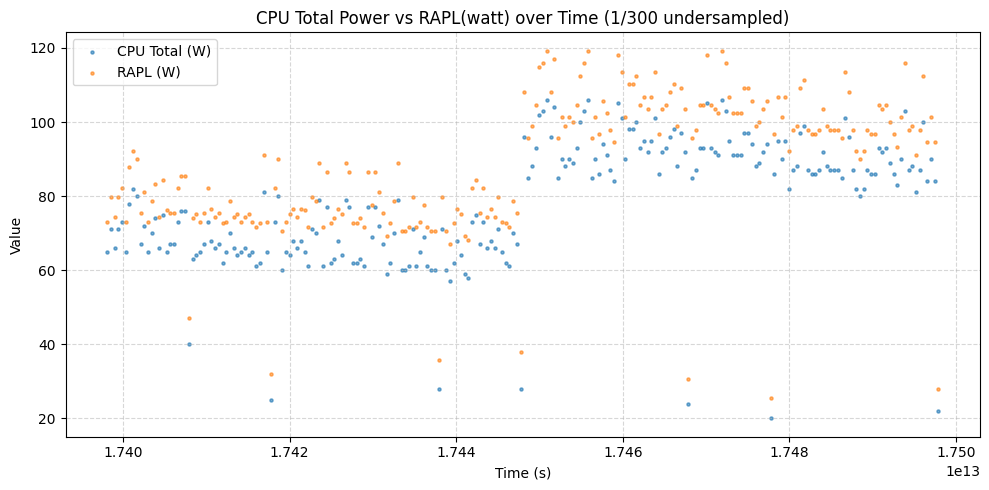

In [15]:
# this section calculates power coverage. 
# for each measurement, minor and major rail power split is used to derive the efficiency factor, which is then used to calculate the PSU efficiency cost
minor_rails = ["I_2", "J_2", "A_2", "B_2", "C_2", "D_2", "V_2"]
major_rails = ["H_2", "K_2", "O_2", "P_2", "Q_2", "R_2", "U_2", "Y_2", "Z_2"]
rapl_teensy_merged["minor_rails_total"] = rapl_teensy_merged[minor_rails].sum(axis=1)
rapl_teensy_merged["major_rails_total"] = rapl_teensy_merged[major_rails].sum(axis=1)

print(rapl_teensy_merged["minor_rails_total"].max())
print(rapl_teensy_merged["major_rails_total"].max())

#load modifiers 
# something to note about images: the top is actually Y = 0, so images are all backwards in terms of the Y value. Do not forget this during processing.
modifier_path = "C:/Users/andyh/Downloads/serialreceive/adjustmentFactor/modifier.npy"
modifier_array = np.load(modifier_path)
MAX_X_VAL = 900
MAX_Y_VAL = 160
print(modifier_array.shape)
max_x = modifier_array.shape[1]
max_y = modifier_array.shape[0]


coverage_preprocessing = pd.DataFrame()
coverage_preprocessing["minor_rails_y"] = max_y - (rapl_teensy_merged["minor_rails_total"] / MAX_Y_VAL * max_y).astype(int) # again this is because in images Y = 0 is the top
coverage_preprocessing["major_rails_x"] = (rapl_teensy_merged["major_rails_total"] / MAX_X_VAL * max_x).astype(int)
print(coverage_preprocessing["minor_rails_y"].min())
print(coverage_preprocessing["major_rails_x"].max())

ix = coverage_preprocessing["major_rails_x"].to_numpy()
iy = coverage_preprocessing["minor_rails_y"].to_numpy()

rapl_teensy_merged["psu_multiplier"] = modifier_array[iy, ix]
print(rapl_teensy_merged["psu_multiplier"].max())
print(rapl_teensy_merged["psu_multiplier"].min())

rapl_teensy_merged["psu_watt"] = rapl_teensy_merged["abs_total"] * (1 - rapl_teensy_merged["psu_multiplier"])
rapl_teensy_merged["psu_adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
print(rapl_teensy_merged["psu_watt"].max())
print(rapl_teensy_merged["psu_watt"].min())

temp_df_for_display = pd.DataFrame()
temp_df_for_display["adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
temp_df_for_display["abs_total"] = rapl_teensy_merged["abs_total"]
temp_df_for_display["timestamp"] = rapl_teensy_merged["timestamp"]
plot_cpu_vs_energy(temp_df_for_display, time_col="timestamp",cpu_col="abs_total", energy_col="adjusted_total", sample_factor=300)





In [36]:
def trapezoid (df, col= "cpu_total"): 

    # time differences (seconds)
    dt = df["timestamp"].diff() / 1e9
    df["timestamp_s"] = df["timestamp"] / 1e9

    # trapezoid: average power * time
    #energy_joules = ((df[col][:-1].values + df[col][1:].values) / 2 * dt[1:].values).sum() #naive trapezoid 
    energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid

    # convert to kWh
    energy_kwh = energy_joules / 3_600_000

    print(col)
    print("Energy (J):", energy_joules)
    print("Energy (kWh):", energy_kwh)
    return energy_kwh

In [24]:
rapl_teensy_merged['NIC'] = rapl_teensy_merged['I_2']
rapl_teensy_merged['DRAM'] = rapl_teensy_merged['P_2'] + rapl_teensy_merged['Q_2'] + rapl_teensy_merged['R_2'] + rapl_teensy_merged['A_2'] + rapl_teensy_merged['C_2']
# rapl_teensy_merged['cpu_total']
rapl_teensy_merged['DISK'] = rapl_teensy_merged['U_2'] + rapl_teensy_merged['V_2']

total_j = trapezoid(rapl_teensy_merged, col='psu_adjusted_total')

print(trapezoid(rapl_teensy_merged, col='NIC'))
print(trapezoid(rapl_teensy_merged, col='DRAM'))
print(trapezoid(rapl_teensy_merged, col='cpu_total'))
print(trapezoid(rapl_teensy_merged, col='DISK'))
print(trapezoid(rapl_teensy_merged, col='abs_total'))

mainboard_ratio = 1 - trapezoid(rapl_teensy_merged, col='psu_watt')/total_j - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='DISK')/total_j - trapezoid(rapl_teensy_merged, col='NIC')/total_j

rapl_unaccounted_ratio = 1 - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j

data_sensor = [
    ("CPU",   "#3E7695", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j),
    ("DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='DRAM')/total_j),
    ("DISK", "#DD8A52", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#C44E52", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#255430", mainboard_ratio ),
    ("PSU", "#32CD32", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_PKG underestimation",   "#696969", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("RAPL_DRAM underestimation",   "#a1a1a1", trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j ),
    ("DISK", "#969696", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#8a8a8a", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#3d3d3d", mainboard_ratio ),
    ("PSU", "#808080", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl_legend = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("Unaccounted", "#696969", rapl_unaccounted_ratio)
]

psu_adjusted_total
Energy (J): 8857.087752018577
Energy (kWh): 0.0024603021533384935
NIC
Energy (J): 206.0785984385093
Energy (kWh): 5.7244055121808135e-05
5.7244055121808135e-05
DRAM
Energy (J): 522.4240952452928
Energy (kWh): 0.00014511780423480356
0.00014511780423480356
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.0018183106313164408
0.0018183106313164408
DISK
Energy (J): 533.2034459710867
Energy (kWh): 0.00014811206832530187
0.00014811206832530187
abs_total
Energy (J): 7807.629395397076
Energy (kWh): 0.0021687859431658543
0.0021687859431658543
psu_watt
Energy (J): 1049.4583566215015
Energy (kWh): 0.0002915162101726393
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.0018183106313164408
DRAM
Energy (J): 522.4240952452928
Energy (kWh): 0.00014511780423480356
DISK
Energy (J): 533.2034459710867
Energy (kWh): 0.00014811206832530187
NIC
Energy (J): 206.0785984385093
Energy (kWh): 5.7244055121808135e-05
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.001818310631

C:\Users\andyh\AppData\Local\Temp\ipykernel_14992\1457331785.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [21]:
import matplotlib.pyplot as plt

def autopct_conditional(pct, threshold=5):
    return f"{pct:.1f}%" if pct >= threshold else ""

def plot_pie_from_tuples(data, filename=None, dpi=300, title="default_title"):
    """
    Plot a pie chart given a list of (name, color, value) tuples.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label:str, color:str, value:float).
    filename : str or None
        If given, saves to file (pdf, png, svg depending on extension).
    dpi : int
        DPI only used for raster formats. Ignored for vector formats.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    labels  = [t[0] for t in data]
    colors  = [t[1] for t in data]
    values  = [t[2] for t in data]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_title(title, pad=20)
    ax.pie(
        
        values,
        #labels=labels,
        colors=colors,
        autopct=lambda pct: autopct_conditional(pct, threshold=1),
        startangle=90,
        pctdistance=1.2,
    )
    ax.axis('equal')  # keep circular

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=dpi)

    return fig, ax

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def legend_only(data, filename=None, ncol=1, fontsize=12):
    """
    Generate a legend-only figure.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label, color) OR (label, color, value).
        Value is ignored.
    filename : str, optional
        If provided, saves the legend (pdf/png/svg).
    ncol : int
        Number of legend columns.
    fontsize : int
        Legend font size.

    Returns
    -------
    fig : Figure
    """

    # handle (label, color) and (label, color, value)
    labels = [t[0] for t in data]
    colors = [t[1] for t in data]

    # Create dummy handles
    handles = [Patch(facecolor=c, edgecolor='none') for c in colors]

    # Create figure with no axes
    fig = plt.figure(figsize=(3, 0.4*len(data)))
    
    legend = fig.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        ncol=ncol,
        fontsize=fontsize,
    )

    # Remove all padding around the figure
    plt.tight_layout(pad=0)

    if filename:
        fig.savefig(filename, bbox_inches="tight")

    return fig



<Figure size 300x120 with 0 Axes>

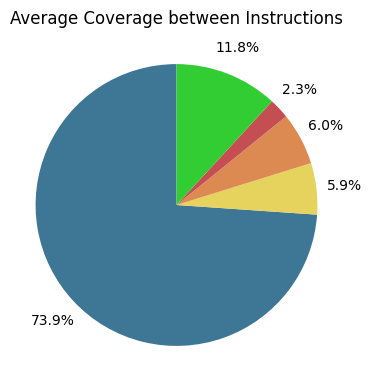

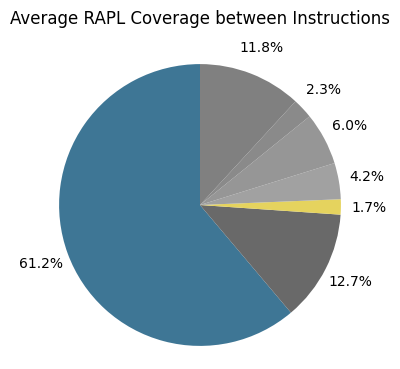

<Figure size 300x240 with 0 Axes>

<Figure size 300x120 with 0 Axes>

In [25]:
plot_pie_from_tuples(data_sensor, title="Average Coverage between Instructions", filename="pie_instructions.png")
plot_pie_from_tuples(data_rapl, title="Average RAPL Coverage between Instructions", filename="pie_rapl_instructions.png")

legend_only(data_sensor, filename="legend.png")
legend_only(data_rapl_legend, filename="legend_rapl.png")

In [20]:
# we really should just have a giant JSON about experiment statistics that is spit out by every benchmark next time, or a list, or a pickle, whatever isnt this bullshit.
segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]
df_partitions = []
prev = -1
for segment in segments:
    if (prev == -1):
        prev = segment
        continue 
    else: 
        df_partitions.append(rapl_teensy_merged[
            rapl_teensy_merged["timestamp"].between(
                prev,
                segment,
                inclusive="both"   # use "both" if you want inclusive
            )]
        )
        prev=segment
        

In [38]:
print(rapl_teensy_merged.columns)
mean_cpu = rapl_teensy_merged["cpu_total"].mean()
mean_power = rapl_teensy_merged["power"].mean()

print("Mean CPU total:", mean_cpu)
print("Mean Power:", mean_power)

def trapezoid (df, col= "cpu_total"): 

    # time differences (seconds)
    dt = df["timestamp"].diff() / 1e9
    df["timestamp_s"] = df["timestamp"] / 1e9

    # trapezoid: average power * time
    #energy_joules = ((df[col][:-1].values + df[col][1:].values) / 2 * dt[1:].values).sum() #naive trapezoid 
    energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid

    # convert to kWh
    energy_kwh = energy_joules / 3_600_000

    print(col)
    print("Energy (J):", energy_joules)
    print("Energy (kWh):", energy_kwh)
    return energy_kwh

print(f"sum ={rapl_teensy_merged["energy"].sum()}??? probably wrong")


kwh1 = trapezoid(rapl_teensy_merged, col= "cpu_total")
kwh2 = trapezoid(rapl_teensy_merged, col= "power")
print(kwh2/kwh1) 



Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'dram_rapl', 'timestamp_1', 'timestamp_2', 'A_2', 'B_2', 'C_2',
       'D_2', 'H_2', 'I_2', 'J_2', 'K_2', 'Y_2', 'Z_2', 'O_2', 'P_2', 'Q_2',
       'R_2', 'U_2', 'V_2', 'timestamp_s_2', 'timestamp_2_2', 'timestamp_diff',
       'cpu_total', 'abs_total', 'timestamp_s'],
      dtype='object')
Mean CPU total: 132.99561940214093
Mean Power: 118.97032
sum =11569.443359375??? probably wrong
cpu_total
Energy (J): 13858.175160401915
Energy (kWh): 0.003849493100111643
power
Energy (J): 12392.996826379625
Energy (kWh): 0.0034424991184387847
0.8942733572737006


C:\Users\andyh\AppData\Local\Temp\ipykernel_20088\1189314007.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [22]:
for df_partition in df_partitions:
    kwh1 = trapezoid(df_partition, col="power")
    kwh2 = trapezoid(df_partition, col="cpu_total")
    print(kwh1/kwh2)

power
Energy (J): 475.1493237965543
Energy (kWh): 0.00013198592327682066
cpu_total
Energy (J): 574.4263046566375
Energy (kWh): 0.00015956286240462154
0.8271719451994354
power
Energy (J): 445.406307023763
Energy (kWh): 0.0001237239741732675
cpu_total
Energy (J): 541.8770442159821
Energy (kWh): 0.00015052140117110613
0.8219693227053043
power
Energy (J): 435.77235049011034
Energy (kWh): 0.00012104787513614176
cpu_total
Energy (J): 531.0167092129832
Energy (kWh): 0.0001475046414480509
0.8206377368726607
power
Energy (J): 423.15045815217223
Energy (kWh): 0.00011754179393115895
cpu_total
Energy (J): 517.9445992792243
Energy (kWh): 0.00014387349979978455
0.8169801533620229
power
Energy (J): 430.4799070303318
Energy (kWh): 0.00011957775195286994
cpu_total
Energy (J): 522.6604748721202
Energy (kWh): 0.0001451834652422556
0.8236320282984049
power
Energy (J): 653.3300835541932
Energy (kWh): 0.00018148057876505365
cpu_total
Energy (J): 784.8917547457404
Energy (kWh): 0.00021802548742937234
0.83238

C:\Users\andyh\AppData\Local\Temp\ipykernel_25592\559216606.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_25592\559216606.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size between two independent samples.
    δ ∈ [-1, 1]; magnitude interpreted as:
      |δ| < 0.147 → negligible
      |δ| < 0.33  → small
      |δ| < 0.474 → medium
      |δ| ≥ 0.474 → large
    """
    nx, ny = len(x), len(y)
    # count all pairwise comparisons
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    delta = (gt - lt) / (nx * ny)
    return delta


def compare_column_means_nonparametric(df, time_col="timestamp_1",
                                       start1=6.52e13, start2=6.56e13, window=500,
                                       cols_range=range(ord('A'), ord('Z')+1)):
    """
    Compare A_2–Z_2 columns between two time windows using non-parametric tests.
    Reports direction, significance (Mann–Whitney U), and effect size (Cliff's Delta).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp and sensor columns.
    time_col : str
        Timestamp column (nanoseconds).
    start1, start2 : float
        Center timestamps for the two regions.
    window : int
        Number of samples before and after each timestamp to include.
    cols_range : iterable
        Character range to define A–Z columns.

    Returns
    -------
    pd.DataFrame
        Per-column statistics: mean_before, mean_after, delta_mean,
        U_stat, p_value, direction, cliffs_delta, and effect_magnitude.
    """

    # Build expected column names: A_2, B_2, ..., Z_2
    cols = [f"{chr(c)}_2" for c in cols_range if f"{chr(c)}_2" in df.columns]

    # Find closest indices to given timestamps
    idx1 = (df[time_col] - start1).abs().idxmin()
    idx2 = (df[time_col] - start2).abs().idxmin()

    # Define window slices
    slice1 = df.iloc[max(0, idx1 - window): idx1 + window]
    slice2 = df.iloc[max(0, idx2 - window): idx2 + window]

    results = []

    for col in cols:
        x1 = slice1[col].dropna().to_numpy()
        x2 = slice2[col].dropna().to_numpy()

        if len(x1) < 10 or len(x2) < 10:
            continue  # skip if too few points

        # Non-parametric Mann–Whitney U test
        U, p = mannwhitneyu(x1, x2, alternative="two-sided")

        mean1, mean2 = x1.mean(), x2.mean()
        delta_mean = mean2 - mean1
        direction = "increase" if delta_mean > 0 else "decrease"

        # Cliff's Delta effect size
        delta = cliffs_delta(x1, x2)
        magnitude = (
            "negligible" if abs(delta) < 0.147 else
            "small" if abs(delta) < 0.33 else
            "medium" if abs(delta) < 0.474 else
            "large"
        )

        results.append({
            "column": col,
            "mean_before": mean1,
            "mean_after": mean2,
            "delta_mean": delta_mean,
            "abs_delta": abs(delta_mean),
            "U_stat": U,
            "p_value": p,
            "direction": direction,
            "cliffs_delta": delta,
            "effect_magnitude": magnitude
        })

    result_df = pd.DataFrame(results).sort_values(["p_value", "abs_delta"])

    print("Top statistically significant changes:")
    print(result_df.head(5))
    return result_df

print(compare_column_means_nonparametric(rapl_teensy_merged))

In [ ]:
import pandas as pd
import re

def rename_single_letter_cols(df: pd.DataFrame, suffix: str = "_2") -> pd.DataFrame:
    """
    Rename all single-letter column names (case-insensitive) by appending a suffix.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    suffix : str, optional
        String to append to single-letter columns (default '_2').

    Returns
    -------
    pd.DataFrame
        New DataFrame with renamed columns.
    """
    rename_map = {
        col: f"{col}{suffix}" for col in df.columns
        if re.fullmatch(r"[A-Za-z]", str(col))
    }
    return df.rename(columns=rename_map)

In [ ]:
df_onlyTeensy = rename_single_letter_cols(df)
df_onlyTeensy["timestamp_1"] = df_onlyTeensy["timestamp"] 
print(compare_column_means_nonparametric(df_onlyTeensy))
df_onlyTeensy["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
df_onlyTeensy["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])

plot_cpu_vs_energy(df_onlyTeensy, time_col="timestamp", cpu_col="cpu_total", energy_col="abs_total", sample_factor=1000)


here we identify P, Q, R, A and C as the main contributor to this increase. 

We identified using time stamps that the benchmark that cause this to occur is 549.fotonik3d_r refrate base

In [ ]:
import matplotlib.pyplot as plt

def plot_cpu_vs_rapl(df, cpu_col="cpu_total", rapl_col="power"):
    """
    Scatter plot of RAPL energy vs CPU total power.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing cpu_total and energy columns.
    cpu_col : str, default 'cpu_total'
        Column name for CPU total (x-axis).
    rapl_col : str, default 'energy'
        Column name for RAPL energy (y-axis).
    """
    df = df.iloc[::100, :]
    plt.figure(figsize=(7, 5))
    plt.scatter(df[cpu_col], df[rapl_col], s=5, alpha=0.6, color="tab:blue")

    plt.xlabel("CPU Total Power (W)")
    plt.ylabel("RAPL Power (W)")
    plt.title("RAPL Power vs CPU Total Power")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_cpu_vs_rapl(rapl_teensy_running_average)
plot_cpu_vs_rapl(rapl_teensy_running_average,cpu_col="abs_total")

In [ ]:
print(rapl_teensy_merged.columns)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap_2d_correlation(df, col_x, col_y, bins=80, cmap="plasma"):
    """
    Create a 2D heatmap (binned density) between two numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    col_x : str
        First column name
    col_y : str
        Second column name
    bins : int
        Number of bins along both axes (default 80)
    cmap : str
        Heatmap color scheme
        
    Returns
    -------
    None
    """

    # Drop NaN
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].astype(np.float32).to_numpy()
    y = data[col_y].astype(np.float32).to_numpy()

    # 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)

    #ceiling
    ceiling = np.percentile(heatmap, 97)   # keep bottom % dynamic
    heatmap_clipped = np.clip(heatmap, 0, ceiling)

    # Log scale (add epsilon to prevent log(0))
    heatmap_log = np.log1p(heatmap)

    

    # Plot
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        heatmap_clipped.T,
        cmap=cmap,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        square=True
    )

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"2D Heatmap: {col_x} vs {col_y}")
    plt.tight_layout()
    plt.show()
heatmap_2d_correlation(rapl_teensy_running_average, "cpu_total_bw", "power_bw", bins=60)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def show_raw_distributions(
        df: pd.DataFrame,
        col1: str,
        col2: str,
        step_size: float,
        overlay=True
    ):
    """
    Show the distribution of raw observations between two numeric columns
    using user-defined bin step size.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    col1 : str
        First column name
    col2 : str
        Second column name
    step_size : float
        Histogram bin width
    overlay : bool
        If True → overlay histograms; otherwise → side-by-side subplots

    Returns
    -------
    (counts1, bins), (counts2, bins)
    """

    # Extract values
    vals1 = df[col1].dropna()
    vals2 = df[col2].dropna()

    # Determine global bin range
    minv = min(vals1.min(), vals2.min())
    maxv = max(vals1.max(), vals2.max())

    bins = np.arange(minv, maxv + step_size, step_size)

    counts1, edges1 = np.histogram(vals1, bins=bins)
    counts2, edges2 = np.histogram(vals2, bins=bins)

    # Plot
    if overlay:
        plt.figure(figsize=(8,4))
        plt.hist(vals1, bins=bins, alpha=0.5, label=col1)
        plt.hist(vals2, bins=bins, alpha=0.5, label=col2)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title("Raw Value Distributions")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
        axs[0].hist(vals1, bins=bins)
        axs[0].set_title(col1)
        axs[1].hist(vals2, bins=bins)
        axs[1].set_title(col2)
        for ax in axs:
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (counts1, edges1), (counts2, edges2)

show_raw_distributions(rapl_teensy_merged, col1="cpu_total", col2="power", step_size=0.1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_time_value_heatmap(
        df: pd.DataFrame,
        time_col: str,
        value_col: str,
        time_step: float,
        value_step: float,
        cmap="viridis"
    ):
    """
    Plots a 2D heatmap of (time vs value) binned by given step sizes.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    time_col : str
        Timestamp column
    value_col : str
        Value column
    time_step : float
        Bin width along time axis
    value_step : float
        Bin width along value axis
    cmap : str
        Matplotlib colormap

    Returns
    -------
    H, xedges, yedges
        2D histogram counts and edges
    """

    t = df[time_col].values
    v = df[value_col].values

    # Compute bins
    t_min, t_max = t.min(), t.max()
    v_min, v_max = v.min(), v.max()

    t_bins = np.arange(t_min, t_max + time_step, time_step)
    v_bins = np.arange(v_min, v_max + value_step, value_step)

    # 2D histogram
    H, xedges, yedges = np.histogram2d(t, v, bins=[t_bins, v_bins])

    plt.figure(figsize=(10,4))
    plt.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading='auto')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(f"Heatmap of {value_col} over time")
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

    return H, xedges, yedges

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="cpu_total",
    time_step=10_000_000_000,
    value_step=1
)

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="energy",
    time_step=10_000_000_000,
    value_step=1
)

In [ ]:
import scipy.stats as stats
import numpy as np

def nonparametric_correlation(df, col_x="cpu_total", col_y="power"):
    """
    Compute non-parametric correlation between two columns (Spearman and Kendall).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing both columns.
    col_x : str
        First variable (e.g. CPU total power).
    col_y : str
        Second variable (e.g. RAPL or measured power).

    Returns
    -------
    dict
        Spearman and Kendall correlation results.
    """
    # Drop missing values
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].to_numpy()
    y = data[col_y].to_numpy()

    # Spearman rank correlation (monotonic relationship)
    spearman_rho, spearman_p = stats.spearmanr(x, y)

    # Kendall Tau correlation (ordinal consistency)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    results = {
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "kendall_tau": kendall_tau,
        "kendall_p": kendall_p,
        "n": len(data)
    }

    print(f"Spearman ρ = {spearman_rho:.4f} (p = {spearman_p:.3e})")
    print(f"Kendall τ = {kendall_tau:.4f} (p = {kendall_p:.3e})")
    print(f"Samples used: {len(data)}")

    return results

print(nonparametric_correlation(rapl_teensy_merged))


In [ ]:
print(nonparametric_correlation(rapl_teensy_merged, col_x="A_2", col_y="C_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Y_2", col_y="Z_2")) #sanity test here, Y and Z is both CPU 
print(nonparametric_correlation(rapl_teensy_merged, col_x="R_2", col_y="P_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Q_2", col_y="P_2"))




In [ ]:
# CHOICE 1
def sum_y_z_with_timestamp(df: pd.DataFrame, col_y: str = "Y", col_z: str = "Z") -> pd.DataFrame:
    """
    Return a new DataFrame with timestamp and the sum of col_y and col_z.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp and sensor columns.
        col_y (str): Name of first column to sum (default: "Y")
        col_z (str): Name of second column to sum (default: "Z")
    
    Returns:
        pd.DataFrame: DataFrame with 'timestamp' and a new column 'Y_plus_Z'
    """
    return pd.DataFrame({
        "timestamp": df["timestamp"],
        f"{col_y}_plus_{col_z}": df[col_y] + df[col_z]
    })

result = sum_y_z_with_timestamp(corrected_df)
print(result)

In [ ]:
import pandas as pd
import numpy as np

def analyze_variance(df, col):
    """
    Compute descriptive variance statistics for a numeric column.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    col : str
        Name of the numeric column to analyze.

    Returns
    -------
    dict
        Dictionary containing mean, variance, std, coefficient of variation, and IQR.
    """
    x = df[col].dropna()

    stats = {
        "count": len(x),
        "mean": float(np.mean(x)),
        "variance": float(np.var(x, ddof=1)),  # sample variance
        "std_dev": float(np.std(x, ddof=1)),
        "coefficient_of_variation": float(np.std(x, ddof=1) / np.mean(x)) if np.mean(x) != 0 else np.nan,
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "iqr": float(np.percentile(x, 75) - np.percentile(x, 25))
    }

    print(f"--- Variance Analysis for '{col}' ---")
    for k, v in stats.items():
        print(f"{k:>25}: {v}")
    return stats
print(analyze_variance(rapl_teensy_merged, "power"))
print(analyze_variance(rapl_teensy_merged, "cpu_total"))


In [ ]:
#check normality at points
import numpy as np
import pandas as pd
from scipy.stats import shapiro, normaltest, anderson

def test_local_normality_at_points(
    df: pd.DataFrame,
    timestamp_col: str,
    value_col: str,
    points: list,
    N: int = 20,
    alpha: float = 0.05,
    method: str = "shapiro"
):
    """
    For each timestamp in `points`, find the nearest timestamp in the DataFrame,
    extract a window of N samples centered on it, and test if that segment is normally distributed.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with timestamp and value columns.
    timestamp_col : str
        Name of the timestamp column (must be integer-like, sorted ascending).
    value_col : str
        Name of the value column to test.
    points : list[float or int]
        List of timestamps (e.g., 1.03e13) where normality should be checked.
    N : int, optional
        Number of samples in the local window (default 20).
    alpha : float, optional
        Significance level for normality tests (default 0.05).
    method : {'shapiro', 'dagostino', 'anderson'}
        Statistical test to use for normality.

    Returns
    -------
    pd.DataFrame
        Columns: ['target_timestamp', 'nearest_timestamp', 'index', 'p_value', 'is_normal']
    """
    timestamps = df[timestamp_col].to_numpy(dtype=np.uint64)
    values = df[value_col].to_numpy(dtype=float)
    half = N // 2

    results = []
    for p in points:
        # Convert to uint64-compatible int
        p_int = np.uint64(round(p))
        # Find nearest index
        idx = np.abs(timestamps - p_int).argmin()
        start = max(0, idx - half)
        end = min(len(df), idx + half + 1)
        window = values[start:end]

        if len(window) < 3:
            results.append((p, timestamps[idx], idx, np.nan, np.nan))
            continue

        if method == "shapiro":
            stat, pval = shapiro(window)
            is_norm = pval > alpha
        elif method == "dagostino":
            stat, pval = normaltest(window)
            is_norm = pval > alpha
        elif method == "anderson":
            res = anderson(window)
            idx_crit = np.searchsorted(res.significance_level, alpha * 100, side="right") - 1
            idx_crit = np.clip(idx_crit, 0, len(res.critical_values) - 1)
            is_norm = res.statistic < res.critical_values[idx_crit]
            pval = np.nan
        else:
            raise ValueError(f"Unknown method: {method}")

        results.append((p, timestamps[idx], idx, pval, is_norm))

    return pd.DataFrame(results, columns=[
        "target_timestamp", "nearest_timestamp", "index", "p_value", "is_normal"
    ])

points = [6.52e13, 6.58e13]

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "power", points, N=2000, method="shapiro")
print(res)

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "cpu_total", points, N=2000, method="shapiro")
print(res)


EVERYTHING BEYOND THIS POINT DEPRECATED ------> OCTOBER 21

In [ ]:
#CHOICE 2
def stack_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a new DataFrame with timestamp and the sum of col_y and col_z.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp and sensor columns.
        col_y (str): Name of first column to sum (default: "Y")
        col_z (str): Name of second column to sum (default: "Z")
    
    Returns:
        pd.DataFrame: DataFrame with 'timestamp' and a new column 'Y_plus_Z'
    """
    return pd.DataFrame({
        "timestamp": df["timestamp"],
        #f"SATA": df["U"] + df["V"],
        f"mobo": df["H"] + df["I"] + df["J"] + df["K"]+ df ["O"] + df["P"] + df["Q"] + df["R"],
        f"cpu": df["Z"] + df["Y"]
    })

result = stack_columns(corrected_df)
print(result)

In [ ]:
def convert_timestamp_to_seconds(df: pd.DataFrame, time_col: str = "timestamp",
                                 clock_hz: int = 24_000_000,
                                 new_col: str = "time_seconds") -> pd.DataFrame:
    """
    Convert hardware timestamp ticks to seconds using the given clock speed.
    
    Parameters:
        df (pd.DataFrame): DataFrame with timestamp column in ticks.
        time_col (str): Name of the timestamp column.
        clock_hz (int): Clock frequency in Hz (default: 24 MHz).
        new_col (str): Name of the new column containing time in seconds.
    
    Returns:
        pd.DataFrame: Copy of df with an added 'time_seconds' column.
    """
    result_df = df.copy()
    result_df[new_col] = result_df[time_col] / clock_hz
    return result_df

df_seconds = convert_timestamp_to_seconds(result)
print(df_seconds.head(10))
print(df_seconds.tail(5))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_three_sensors(df: pd.DataFrame,
                       time_col: str = "time_seconds",
                       sensors: list = ["Y_plus_Z"],
                       dpi: int = 200):
    """
    Plot three sensor columns vs. timestamp on the same figure.

    Parameters:
        df (pd.DataFrame): DataFrame containing timestamp and sensor data.
        time_col (str): Column name for timestamp (default: "timestamp").
        sensors (list): List of three column names to plot.
        dpi (int): Figure resolution in DPI (default: 200).
    """
    if len(sensors) != 2:
        print("Please provide exactly three sensor column names.")

    plt.figure(figsize=(10, 5), dpi=dpi)
    
    for sensor in sensors:
        plt.plot(df[time_col], df[sensor],
                 marker='o', markersize=3, linewidth=0.8, label=sensor)

    plt.xlabel("Timestamp")
    plt.ylabel("Sensor Values")
    plt.title("Sensor Readings vs Timestamp")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_three_sensors(df_seconds, time_col="time_seconds")

In [ ]:
import pandas as pd

def convert_time_seconds_to_datetime(df: pd.DataFrame, start_time_str: str) -> pd.DataFrame:
    """
    Convert a column 'time_seconds' (relative seconds) into absolute datetimes
    in the format 'YYYY-MM-DD HH:MM:SS.sss', aligning the first value of 'time_seconds'
    to the provided starting timestamp.

    Example output: 2025-09-30 23:12:32.734

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a 'time_seconds' column.
    start_time_str : str
        Starting time string, e.g. "2025-09-30 23:12:32.734" or "09/18/2025 16:46:04".

    Returns
    -------
    pd.DataFrame
        DataFrame with an added 'datetime' column (string format) and set as index.
    """
    if "time_seconds" not in df.columns:
        raise ValueError("DataFrame must contain a 'time_seconds' column")

    # Try multiple possible formats for safety
    try:
        start_dt = pd.to_datetime(start_time_str, format="%Y-%m-%d %H:%M:%S.%f")
    except ValueError:
        start_dt = pd.to_datetime(start_time_str, format="%m/%d/%Y %H:%M:%S")

    df = df.copy()
    first_val = df["time_seconds"].iloc[0]
    df["time_seconds_adj"] = df["time_seconds"] - first_val

    # Create datetime column
    df["datetime"] = start_dt + pd.to_timedelta(df["time_seconds_adj"], unit="s")

    # Format datetime to desired string format with millisecond precision
    df["datetime"] = df["datetime"].dt.strftime("%Y-%m-%d %H:%M:%S.%f").str[:-3]

    # Set datetime as index
    #df = df.set_index("datetime")

    return df

df_with_dt = convert_time_seconds_to_datetime(df_seconds, "2025-09-30 23:12:45.000")
print(df_with_dt.head(5))
print(df_with_dt.tail(5))
print(df_with_dt.shape)
print(df_with_dt.dropna().shape)
df_with_dt.rename(columns={"timestamp": "timeold"}, inplace=True)
df_with_dt.rename(columns={"datetime": "timestamp"}, inplace=True)
print(df_with_dt.head(5))



In [ ]:
#ONLY USE THIS IF YOU ARE USING LOG FROM HARDWARE MONITOR!!!!!
import os
import pandas as pd

import os
import glob
import pandas as pd

def read_open_hardware_monitor_log(folder: str) -> pd.DataFrame:
    """
    Searches for a CSV file in `folder` that contains 'OpenHardwareMonitorLog' in its name,
    loads it into a pandas DataFrame, and returns a cleaned version.
    
    - Automatically finds the first matching file.
    - Strips whitespace from column names.
    - Parses 'Time' column to datetime and sets it as index.
    - Converts other columns to numeric where possible.
    
    Parameters
    ----------
    folder : str
        Path to the folder containing the OpenHardwareMonitor log CSV.
    
    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with DateTimeIndex.
    
    Raises
    ------
    FileNotFoundError
        If no matching file is found in the folder.
    """
    # Find matching files
    pattern = os.path.join(folder, "*OpenHardwareMonitorLog*.csv")
    matching_files = glob.glob(pattern)

    if not matching_files:
        raise FileNotFoundError(f"No CSV file containing 'OpenHardwareMonitorLog' found in {folder}")

    # Pick the first match (or you could pick the latest by modified time)
    file_path = matching_files[0]

    # Load CSV
    df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Parse 'Time' column if present and set as index
    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
        df = df.set_index("Time")

    # Convert other columns to numeric
    df = df.apply(pd.to_numeric, errors="ignore")

    return df

df_OHML = read_open_hardware_monitor_log("./trace/trace-e2")
print(df_OHML.head(10))

In [ ]:
import pandas as pd

import pandas as pd

def clean_open_hardware_monitor_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and aggregate an OpenHardwareMonitor DataFrame:
    
    1. Drop row 0 (extra info)
    2. Convert datetime-like columns to datetime
    3. Convert all other columns to float
    4. Aggregate CPU load and CPU power into new columns
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame from read_open_hardware_monitor_log()

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with datetime-aware index and numeric columns
    """
    # 1. Drop row 0
    df_clean = df.iloc[1:].copy()

    # 2. Convert datetime-like columns first
    for col in df_clean.columns:
        try:
            # Try parsing; only replace if most values convert successfully
            converted = pd.to_datetime(df_clean[col], format="%m/%d/%Y %H:%M:%S", errors="coerce")
            if converted.notna().mean() > 0.8:  # at least 80% valid datetimes
                df_clean[col] = converted
        except Exception:
            pass

    # 3. Convert remaining columns to float
    for col in df_clean.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_clean[col]):
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # If we have a "Time" column as datetime, make it the index
    if "Time" in df_clean.columns and pd.api.types.is_datetime64_any_dtype(df_clean["Time"]):
        df_clean = df_clean.set_index("Time")

    # 4. Compute cpuload and cpupower
    load_cols = [c for c in df_clean.columns if c.startswith("/intelcpu/0/load/") and any(c.endswith(f"/{i}") for i in range(1, 7))]
    power_cols = [c for c in df_clean.columns if c.startswith("/intelcpu/0/power/") and any(c.endswith(f"/{i}") for i in range(1, 3))]

    if load_cols:
        df_clean["cpuload"] = df_clean[load_cols].sum(axis=1, skipna=True)
    if power_cols:
        df_clean["cpupower"] = df_clean[power_cols].sum(axis=1, skipna=True)

    return df_clean

df_cleaned = clean_open_hardware_monitor_df(df_OHML)
print(df_cleaned.head(19))

In [ ]:
#for turbostat only LOAD TURBO STAT
import os
import pandas as pd

def load_turbostat_log(folder_path: str) -> pd.DataFrame:
    """
    Search for a CSV file containing 'turbostat_log' in its name within the given folder path,
    load it into a pandas DataFrame, and return it.

    Parameters
    ----------
    folder_path : str
        Path to the folder where the CSV file is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the contents of the matched CSV file.

    Raises
    ------
    FileNotFoundError
        If no matching file is found.
    """
    # Ensure folder exists
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"The folder path '{folder_path}' does not exist.")

    # Search for matching file
    for file_name in os.listdir(folder_path):
        if "turbostat_log" in file_name and file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            print(f"✅ Found file: {file_path}")
            return pd.read_csv(file_path)

    # If no file found
    raise FileNotFoundError(f"No CSV file containing 'turbostat_log' found in {folder_path}.")

df = load_turbostat_log("C:/Users/andyh/Downloads/serialreceive/trace/turbostat")
print(df.head())
df_rawturbostat = df

df_rawturbostat = df_rawturbostat.drop('gfx_watt', axis=1)
df_rawturbostat = df_rawturbostat.drop('pkg_j', axis=1)
print(df_rawturbostat.head())





In [ ]:
import os
import pandas as pd

def load_cpu_usage_log(folder_path: str) -> pd.DataFrame:
    """
    Searches a directory (recursively) for a CSV file containing 'cpu_usage_log'
    in its name and returns it as a pandas DataFrame.

    Args:
        folder_path (str): The path to the directory to search.

    Returns:
        pd.DataFrame: The loaded DataFrame.

    Raises:
        FileNotFoundError: If no matching CSV file is found.
    """
    # Walk through directory and subdirectories
    for root, _, files in os.walk(folder_path):
        for file in files:
            if "cpu_usage_log" in file and file.endswith(".csv"):
                file_path = os.path.join(root, file)
                print(f"✅ Found file: {file_path}")
                return pd.read_csv(file_path)

    raise FileNotFoundError(f"No file containing 'cpu_usage_log' found in {folder_path}")

df = load_cpu_usage_log("C:/Users/andyh/Downloads/serialreceive/trace/turbostat")
print(df.head())

#might need some cleaning 
df = df.dropna()
print(df.head(5))

df_raw_cpuusage = df



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics(df1, df2, df3):
    """
    Plot Y_plus_Z (df1), pkg_watt (df2), and cpu_usage_percent (df3)
    against their common 'timestamp' column.
    
    - Y_plus_Z and pkg_watt share the left y-axis.
    - cpu_usage_percent uses a secondary y-axis.
    - Lines are thin for clarity.
    """

    # --- Convert timestamps to datetime for consistent x-axis ---
    df1 = df1.copy()
    df2 = df2.copy()
    df3 = df3.copy()

    for df in [df1, df2, df3]:
        if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
            df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df.dropna(subset=["timestamp"], inplace=True)

    # --- Create the figure and axes ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Y_plus_Z (df1) and pkg_watt (df2) on the same axis
    ax1.plot(df1["timestamp"], df1["Y_plus_Z"], label="Y + Z", color="tab:blue", linewidth=0.8)
    ax1.plot(df2["timestamp"], df2["pkg_watt"], label="Package Power (W)", color="tab:orange", linewidth=0.8)

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Power / Sensor (W)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # --- Secondary axis for CPU usage ---
    ax2 = ax1.twinx()
    ax2.plot(df3["timestamp"], df3["cpu_usage_percent"], label="CPU Usage (%)", color="tab:red", linewidth=0.8)
    ax2.set_ylabel("CPU Usage (%)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # --- Titles, grid, and legends ---
    fig.suptitle("Sensor (Y+Z), Package Power, and CPU Usage Over Time", fontsize=12)
    fig.autofmt_xdate(rotation=30)
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Combine legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_combined_metrics(df_with_dt, df_rawturbostat, df_raw_cpuusage)


In [ ]:
#old
import matplotlib.pyplot as plt

def plot_cpu_metrics(df: pd.DataFrame):
    """
    Plot cpuload and cpupower over time using matplotlib.
    
    - cpuload is shown on the left y-axis
    - cpupower is shown on the right y-axis
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing at least 'cpuload' and 'cpupower' columns,
        with a DateTimeIndex or a 'Time' column.
    """
    if df.empty:
        print("DataFrame is empty — nothing to plot.")
        return
    
    # Ensure we have a datetime index
    if "Time" in df.columns and not isinstance(df.index, pd.DatetimeIndex):
        df = df.set_index("Time")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left y-axis: CPU Load
    ax1.plot(df.index, df["cpuload"], label="CPU Load (%)", color="tab:blue")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("CPU Load (%)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis: CPU Power
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["cpupower"], label="CPU Power (W)", color="tab:red")
    ax2.set_ylabel("CPU Power (W)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Title and grid
    plt.title("CPU Load and Power Over Time")
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)

    # Show
    fig.tight_layout()
    plt.show()

plot_cpu_metrics(df_cleaned)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics_relative(df_with_dt: pd.DataFrame, df_cleaned: pd.DataFrame):
    """
    Plot mobo, cpu, cpupower (shared left y-axis) and cpuload (right y-axis)
    over a shared timeline, using earliest timestamp as time zero.

    - X-axis shows seconds since earliest timestamp
    - Title shows the starting timestamp (human-readable)
    - Covers full range from earliest of both to latest of both
    """
    # --- Ensure datetime index for df_with_dt
    if "datetime" in df_with_dt.columns:
        df_with_dt = df_with_dt.set_index("datetime")
    df_with_dt.index = pd.to_datetime(df_with_dt.index)

    # --- Ensure datetime index for df_cleaned
    if "Time" in df_cleaned.columns:
        df_cleaned = df_cleaned.set_index("Time")
    df_cleaned.index = pd.to_datetime(df_cleaned.index)

    # --- Determine global start and end time
    global_start = min(df_with_dt.index.min(), df_cleaned.index.min())
    global_end   = max(df_with_dt.index.max(), df_cleaned.index.max())

    # --- Compute relative seconds since global_start
    df_with_dt_rel = df_with_dt.copy()
    df_with_dt_rel["rel_sec"] = (df_with_dt_rel.index - global_start).total_seconds()

    df_cleaned_rel = df_cleaned.copy()
    df_cleaned_rel["rel_sec"] = (df_cleaned_rel.index - global_start).total_seconds()

    # --- Debug info
    print(f"Global start time: {global_start}, end time: {global_end}")
    print(df_with_dt_rel[["rel_sec", "mobo", "cpu"]].head())
    print(df_cleaned_rel[["rel_sec", "cpuload", "cpupower"]].head())

    # --- Plotting
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left y-axis: mobo, cpu, cpupower
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["mobo"], label="Mobo", color="tab:blue")
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["cpu"], label="CPU", color="tab:green")
    ax1.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpupower"], label="CPU Power (W)", color="tab:red")
    ax1.set_xlabel("Time (seconds since start)")
    ax1.set_ylabel("Mobo / CPU / Power (units)")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Right y-axis: cpuload (separate scale)
    ax2 = ax1.twinx()
    #ax2.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpuload"], label="CPU Load (%)", color="tab:orange", alpha=0.7)
    ax2.set_ylabel("CPU Load (%)")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"CPU & Mobo Metrics — Start: {global_start.strftime('%m/%d/%Y %H:%M:%S')}")
    plt.tight_layout()
    plt.show()

# Example usage: 
df_cleaned = df_cleaned.rename(columns={"Unnamed: 0": "Time"})
plot_combined_metrics_relative(df_with_dt, df_cleaned)

In [ ]:
print(df_with_dt.head(5))
print(df_cleaned.head(5))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics_relative(df_with_dt: pd.DataFrame, df_cleaned: pd.DataFrame):
    """
    Plot mobo, cpu, cpupower (shared left y-axis) and cpuload (right y-axis)
    over a shared timeline, using earliest timestamp as time zero.

    - X-axis shows seconds since earliest timestamp
    - Title shows the starting timestamp (human-readable)
    - Covers full range from earliest of both to latest of both
    """
    # --- Ensure datetime index for df_with_dt
    if "datetime" in df_with_dt.columns:
        df_with_dt = df_with_dt.set_index("datetime")
    df_with_dt.index = pd.to_datetime(df_with_dt.index)

    # --- Ensure datetime index for df_cleaned
    if "Time" in df_cleaned.columns:
        df_cleaned = df_cleaned.set_index("Time")
    df_cleaned.index = pd.to_datetime(df_cleaned.index)

    # --- Determine global start and end time
    global_start = min(df_with_dt.index.min(), df_cleaned.index.min())
    global_end   = max(df_with_dt.index.max(), df_cleaned.index.max())

    # --- Compute relative seconds since global_start
    df_with_dt_rel = df_with_dt.copy()
    df_with_dt_rel["rel_sec"] = (df_with_dt_rel.index - global_start).total_seconds()

    df_cleaned_rel = df_cleaned.copy()
    df_cleaned_rel["rel_sec"] = (df_cleaned_rel.index - global_start).total_seconds()

    # --- Debug info
    print(f"Global start time: {global_start}, end time: {global_end}")
    print(df_with_dt_rel[["rel_sec", "mobo", "cpu"]].head())
    print(df_cleaned_rel[["rel_sec", "cpuload", "cpupower"]].head())

    # --- Plotting
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left y-axis: mobo, cpu, cpupower
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["mobo"], label="Mobo", color="tab:blue", linewidth=0.3)
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["cpu"], label="CPU", color="tab:green", linewidth=0.3)
    ax1.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpupower"], label="CPU Power (W)", color="tab:red", linewidth=0.3)
    ax1.set_xlabel("Time (seconds since start)")
    ax1.set_ylabel("Mobo / CPU / Power (units)")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Right y-axis: cpuload (separate scale)
    ax2 = ax1.twinx()
    ax2.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpuload"], label="CPU Load (%)",
             color="tab:orange", alpha=0.7, linewidth=0.3)
    ax2.set_ylabel("CPU Load (%)")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"CPU & Mobo Metrics — Start: {global_start.strftime('%m/%d/%Y %H:%M:%S')}")
    plt.tight_layout()
    plt.show()

# Example usage: 
df_cleaned = df_cleaned.rename(columns={"Unnamed: 0": "Time"})
plot_combined_metrics_relative(df_with_dt, df_cleaned)
